# Lección 2.1 · El idioma de los archivos: FASTA, FASTQ, GenBank, GFF, BED, SAM/BAM y VCF

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-02-formatos-bases-datos/2.1_formatos_archivos.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 2 — Secuencias, formatos y bases de datos** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~3.5 horas | Introductorio–intermedio | Módulo 0 y Módulo 1 |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Ubicar** cada formato en la vida de un análisis: de las lecturas crudas (FASTQ) a las variantes (VCF),
   pasando por la referencia (FASTA), los alineamientos (SAM/BAM) y las anotaciones (GFF/BED).
2. **Leer y escribir** archivos FASTA y FASTQ **desde cero**, sin bibliotecas, entendiendo cada línea.
3. **Convertir** entre calidad Phred, probabilidad de error y carácter ASCII, y **calcular** los errores esperados de
   una lectura.
4. **Dominar** los dos sistemas de coordenadas (0-based semiabierto y 1-based cerrado) y **evitar** el error de uno
   (*off-by-one*), el error más frecuente de la bioinformática.
5. **Interpretar** un registro SAM: posición, **CIGAR** y **FLAG** (decodificando sus bits).
6. **Explicar** por qué existe BAM, qué es un índice y cómo permite saltar directo a una región del genoma.
7. **Leer** un VCF, extraer genotipos y **calcular** frecuencias alélicas.

## 🗺️ Mapa de la clase

1. ¿Por qué existen tantos formatos? La vida de los datos en un análisis
2. FASTA: la secuencia desnuda
3. FASTQ: la secuencia con su "nivel de confianza" (Phred)
4. 🧪 Experimento: simular una corrida de secuenciación y medir su calidad
5. Coordenadas: el error de uno y cómo evitarlo
6. GenBank → GFF3 y BED: las anotaciones
7. SAM: dónde cayó cada lectura (CIGAR y FLAG)
8. BAM e índices: comprimir sin perder el acceso rápido
9. VCF: las diferencias con la referencia
10. Ejercicios, resumen y lecturas

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import gzip, io, re, shutil, time
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

try:
    import Bio
except ImportError:
    %pip install -q biopython
from Bio import SeqIO, Entrez
from Bio.Seq import Seq
Entrez.email = "su.correo@ejemplo.com"     # ← escriba aquí su correo (el NCBI lo pide)
RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

Entorno listo ✔  |  Colab: False


## 1. ¿Por qué existen tantos formatos? La vida de los datos en un análisis

Imagine una cocina profesional. La **receta** se escribe en un papel, los **ingredientes** llegan en cajas con
etiquetas de fecha y calidad, el **plan del día** está en una pizarra y las **quejas de los clientes** en un
libro aparte. Cada cosa tiene su propio soporte porque cada una responde a una pregunta distinta. Nadie guardaría las
quejas de los clientes dentro del saco de harina.

En bioinformática ocurre lo mismo. Un análisis típico de resecuenciación (por ejemplo, buscar mutaciones en el
genoma de un paciente o de un virus) pasa por varias etapas, y **cada etapa produce un archivo con un formato
pensado para su pregunta**:

| Pregunta | Formato | Qué guarda |
|---|---|---|
| ¿Cuál es la secuencia de referencia? | **FASTA** | secuencias "desnudas" con un nombre |
| ¿Qué leyó el secuenciador y con cuánta confianza? | **FASTQ** | lecturas + calidad de cada base |
| ¿Qué dice la base de datos sobre este genoma? | **GenBank** | secuencia + anotaciones + referencias bibliográficas |
| ¿Dónde están los genes, exones, UTRs…? | **GFF3 / GTF** | anotaciones en una tabla de 9 columnas |
| ¿Qué regiones me interesan? | **BED** | intervalos genómicos mínimos (cromosoma, inicio, fin) |
| ¿Dónde cayó cada lectura y cómo encaja? | **SAM / BAM / CRAM** | alineamientos |
| ¿En qué difiere la muestra de la referencia? | **VCF / BCF** | variantes y genotipos |

Casi todos son **archivos de texto con columnas separadas por tabuladores**: se pueden abrir con cualquier editor,
leer con `pandas` o procesar línea por línea. Los formatos binarios (BAM, BCF, CRAM) son versiones comprimidas de
sus hermanos de texto, pensadas para archivos de decenas o cientos de gigabytes.

El siguiente diagrama resume el flujo que seguiremos durante todo el Módulo 2 y buena parte del curso:

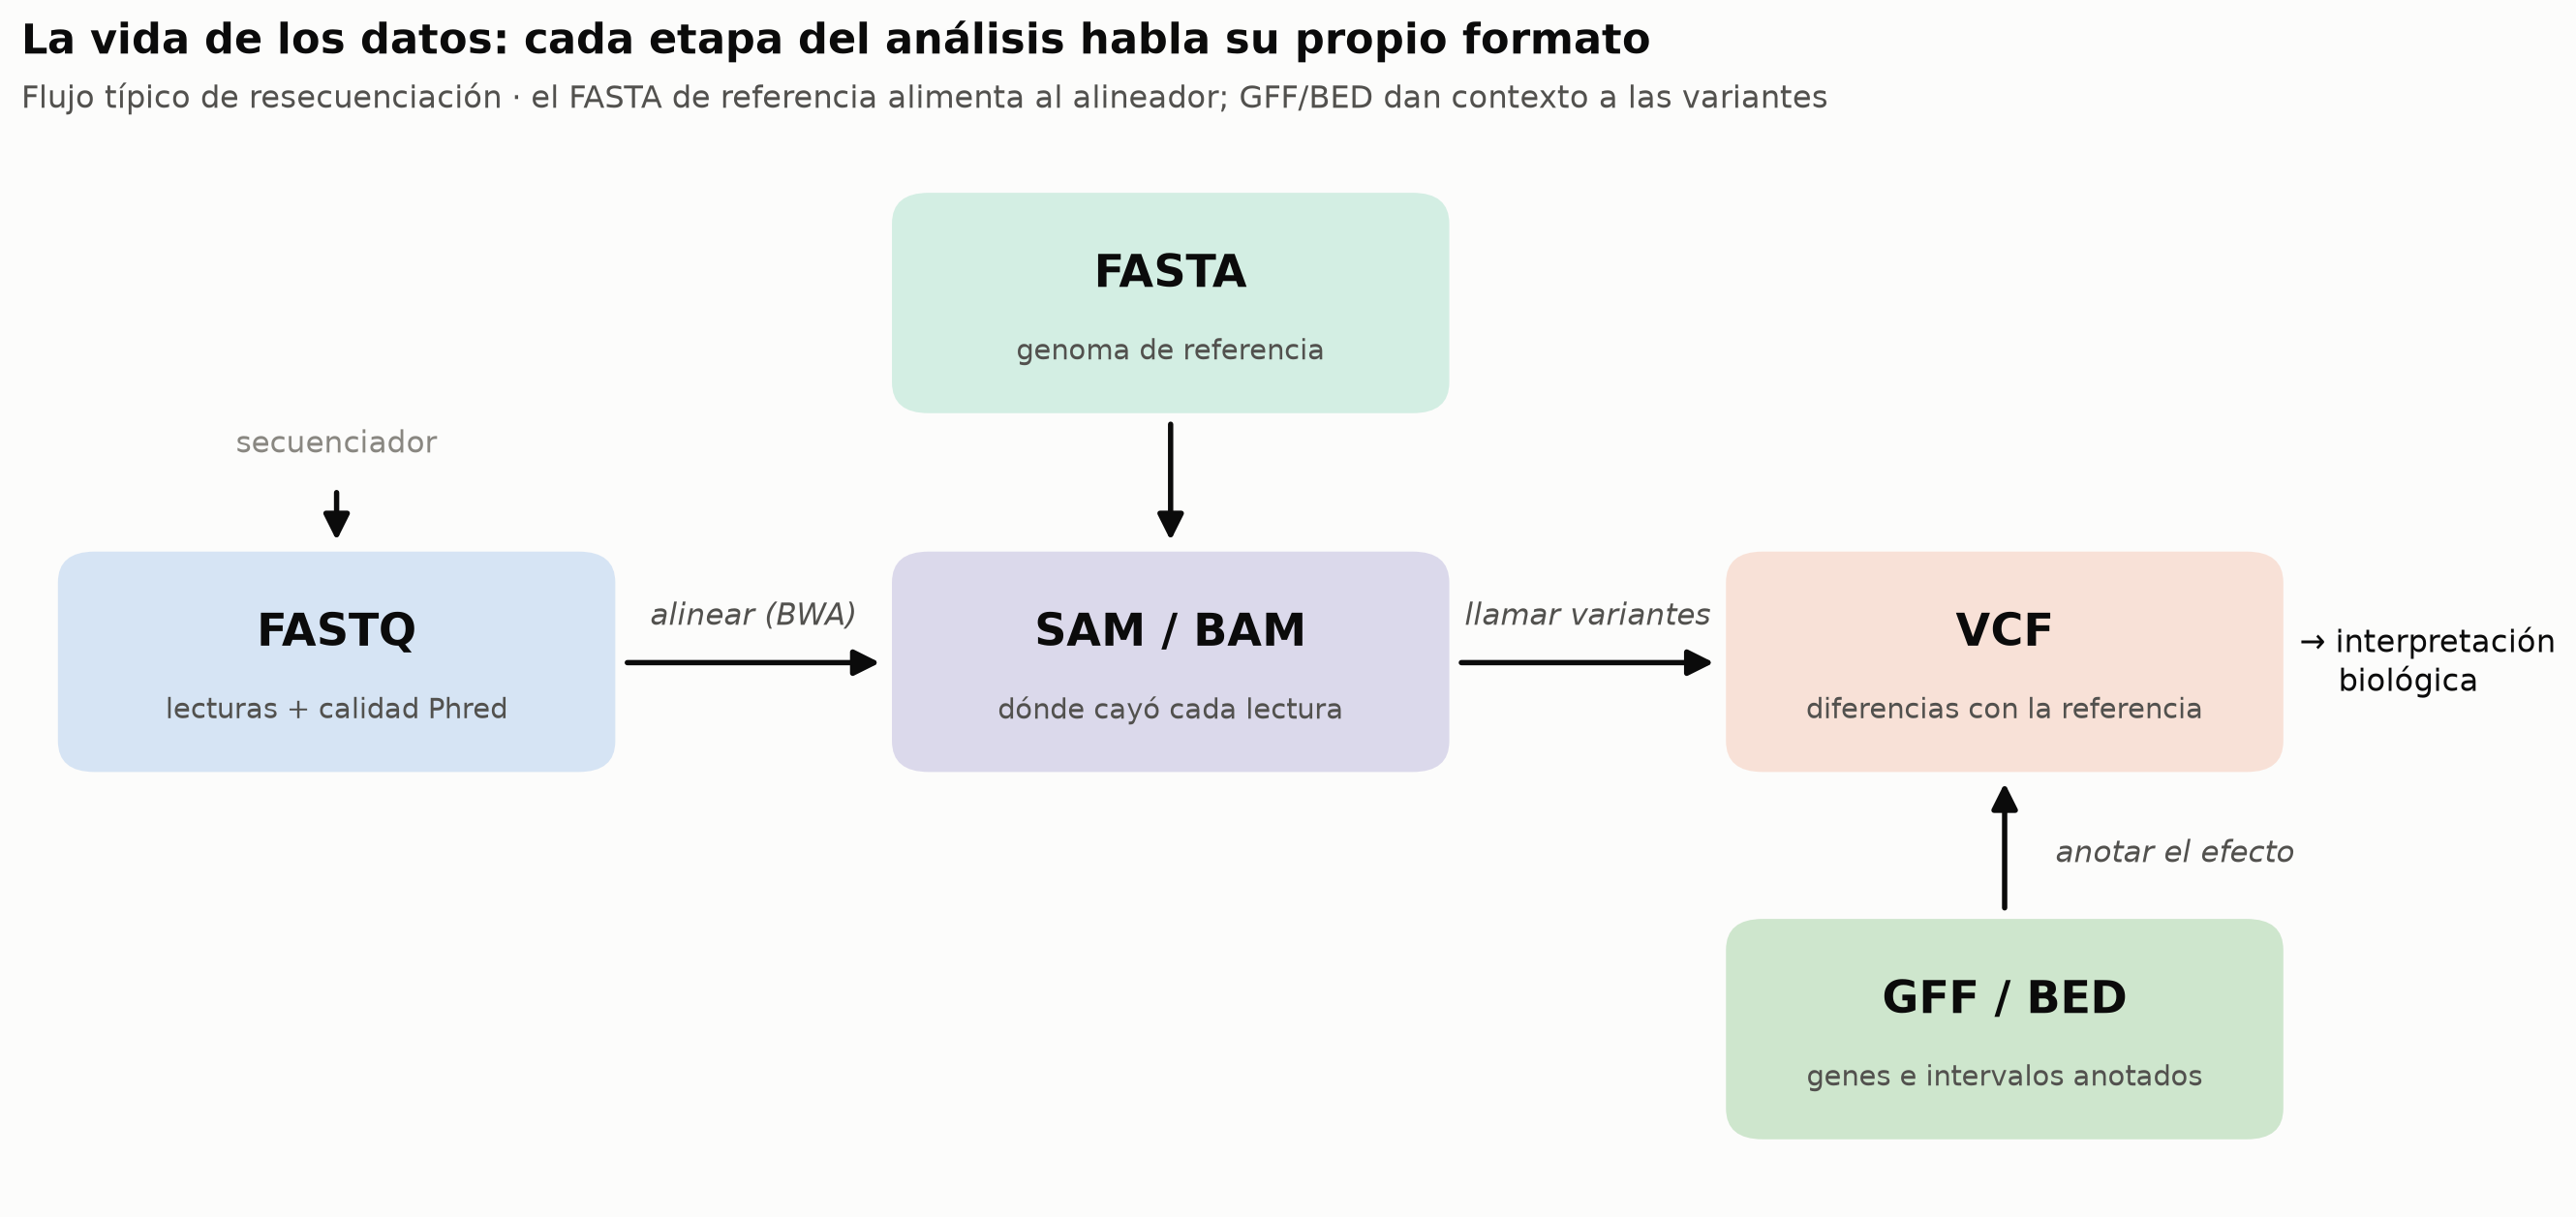

In [2]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(12, 5.6))
ax.set_xlim(0, 12.4); ax.set_ylim(0, 6.2); ax.axis("off")

def box(x, y, name, sub, color, w=2.7, h=1.25):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.18",
                                facecolor=color, alpha=0.18, edgecolor="none"))
    ax.text(x + w / 2, y + h * 0.63, name, ha="center", va="center", fontsize=15, fontweight="bold", color=ec.INK)
    ax.text(x + w / 2, y + h * 0.27, sub, ha="center", va="center", fontsize=9.5, color=ec.INK_2)
    return (x, y, w, h)

def arrow(p0, p1, label=None, dy=0.18, style="-|>"):
    ax.add_patch(FancyArrowPatch(p0, p1, arrowstyle=style, mutation_scale=18, color=ec.INK, lw=1.8))
    if label:
        ax.text((p0[0] + p1[0]) / 2, (p0[1] + p1[1]) / 2 + dy, label, ha="center", va="bottom",
                fontsize=10, color=ec.INK_2, style="italic")

fq  = box(0.2, 2.5, "FASTQ", "lecturas + calidad Phred", ec.BLUE)
fa  = box(4.3, 4.6, "FASTA", "genoma de referencia", ec.AQUA)
sam = box(4.3, 2.5, "SAM / BAM", "dónde cayó cada lectura", ec.VIOLET)
vcf = box(8.4, 2.5, "VCF", "diferencias con la referencia", ec.ORANGE)
gff = box(8.4, 0.35, "GFF / BED", "genes e intervalos anotados", ec.GREEN)
ax.text(1.55, 4.35, "secuenciador", ha="center", fontsize=10, color=ec.MUTED)
arrow((1.55, 4.15), (1.55, 3.8))

arrow((2.95, 3.12), (4.25, 3.12), "alinear (BWA)")
arrow((5.65, 4.55), (5.65, 3.8), None)
arrow((7.05, 3.12), (8.35, 3.12), "llamar variantes")
arrow((9.75, 1.65), (9.75, 2.45), None)
ax.text(10.0, 2.0, "anotar el efecto", fontsize=10, color=ec.INK_2, style="italic", va="center")
ax.text(11.2, 3.12, "→ interpretación\n    biológica", fontsize=10.5, color=ec.INK, va="center")
ec.title(ax, "La vida de los datos: cada etapa del análisis habla su propio formato",
         "Flujo típico de resecuenciación · el FASTA de referencia alimenta al alineador; GFF/BED dan contexto a las variantes")
plt.show()

🔎 **Qué observamos.** El FASTQ es lo único que "sale de la máquina". Todo lo demás es **producto de un cálculo**
(alinear, comparar, anotar) o **conocimiento previo** (la referencia y sus genes). Si un archivo intermedio se
pierde, se puede regenerar; si se pierde el FASTQ, se pierden los datos. Por eso los FASTQ crudos se archivan en
repositorios públicos como el **SRA** del NCBI o el **ENA** europeo.

Para trabajar con datos reales usaremos de nuevo el genoma de SARS-CoV-2 (Lección 0.2). La celda busca primero la
copia del repositorio, luego lo descarga del NCBI y, si todo falla, usa la copia de respaldo en GitHub.

In [3]:
def load_genbank(acc):
    """Carga un GenBank: copia local del repositorio → NCBI → copia de respaldo en GitHub."""
    for local in (f"../data/{acc}.gb", f"{acc}.gb"):
        if os.path.exists(local):
            return SeqIO.read(local, "genbank")
    try:
        with Entrez.efetch(db="nuccore", id=acc, rettype="gbwithparts", retmode="text") as handle:
            text = handle.read()
        print("Descargado del NCBI ✔")
    except Exception as err:
        print("NCBI no respondió (", err, ") → usando la copia del curso")
        text = urllib.request.urlopen(f"{RAW}/data/{acc}.gb").read().decode()
    open(f"{acc}.gb", "w").write(text)
    return SeqIO.read(f"{acc}.gb", "genbank")

sars = load_genbank("NC_045512.2")
ref = str(sars.seq).upper()
CHROM = sars.id
print(sars.description)
print(f"{CHROM}: {len(ref):,} nt")

Severe acute respiratory syndrome coronavirus 2 isolate Wuhan-Hu-1, complete genome
NC_045512.2: 29,903 nt


## 2. FASTA: la secuencia desnuda

El formato FASTA nació en 1985 con el programa del mismo nombre (Lipman y Pearson) y sobrevive porque es
**absurdamente simple**. Es como una lista de contactos escrita a mano: una línea con el nombre y, debajo, el dato.

```
>identificador descripción libre         ← encabezado: empieza con ">"
ATTAAAGGTTTATACCTTCCCAGGTAACAAACCAACCAA  ← secuencia, en una o varias líneas
CTTTCGATCTCTTGTAGATCTGTTCTCTAAACGAACTTT
>otra_secuencia                          ← el siguiente ">" empieza un registro nuevo
ACGT...
```

Reglas que conviene recordar:

* El **identificador** es todo lo que va desde `>` hasta el primer espacio. Muchas herramientas usan **sólo** esa
  parte: si su identificador tiene espacios, lo perderá.
* La secuencia puede partirse en líneas de cualquier longitud (60 u 80 caracteres son lo usual). **El salto de
  línea no es parte de la secuencia.**
* Letras minúsculas suelen indicar regiones **enmascaradas** (repeticiones de baja complejidad), y `N` significa
  "base desconocida".

### Un lector de FASTA desde cero

Leer un FASTA es un buen ejercicio de lógica: recorremos las líneas; si una empieza con `>`, **cerramos** el
registro anterior (si había) y **abrimos** uno nuevo; si no, **pegamos** la línea a la secuencia actual. Al final,
no olvidamos cerrar el último registro. Escribimos la función como un **generador** (`yield`), así puede leer un
archivo de varios gigabytes sin cargarlo entero en memoria.

In [4]:
def parse_fasta(lines):
    """Genera pares (encabezado, secuencia) a partir de las líneas de un FASTA."""
    header, chunks = None, []
    for line in lines:
        line = line.rstrip()
        if not line:
            continue                                   # ignoramos líneas vacías
        if line.startswith(">"):
            if header is not None:
                yield header, "".join(chunks)          # cerramos el registro anterior
            header, chunks = line[1:], []
        else:
            chunks.append(line)
    if header is not None:
        yield header, "".join(chunks)                  # ¡no olvidar el último!

toy = """>gen1 un gen de juguete
ATGGCC
ATTGTA
>gen2 otro
ATGAAATAG
"""
for h, s in parse_fasta(toy.splitlines()):
    print(f"{h!r:28} → {s} ({len(s)} nt)")

'gen1 un gen de juguete'     → ATGGCCATTGTA (12 nt)
'gen2 otro'                  → ATGAAATAG (9 nt)


Ahora escribimos el genoma de SARS-CoV-2 como FASTA con líneas de 60 caracteres, lo volvemos a leer con nuestra
función y verificamos que coincide **letra por letra** con lo que lee Biopython. Siempre que escriba su propio
lector, compárelo contra una implementación de referencia.

In [5]:
def write_fasta(path, records, width=60):
    with open(path, "w") as fh:
        for name, seq in records:
            fh.write(f">{name}\n")
            for i in range(0, len(seq), width):
                fh.write(seq[i:i + width] + "\n")

write_fasta("sars.fasta", [(f"{CHROM} {sars.description}", ref)])
with open("sars.fasta") as fh:
    (h, s), = list(parse_fasta(fh))
print("Primeras líneas del archivo:")
print("".join(open("sars.fasta").readlines()[:4]))
print("¿Idéntico a Biopython?", s == str(SeqIO.read("sars.fasta", "fasta").seq))
print("Tamaño en disco:", f"{os.path.getsize('sars.fasta'):,} bytes para {len(s):,} nt")

Primeras líneas del archivo:
>NC_045512.2 Severe acute respiratory syndrome coronavirus 2 isolate Wuhan-Hu-1, complete genome
ATTAAAGGTTTATACCTTCCCAGGTAACAAACCAACCAACTTTCGATCTCTTGTAGATCT
GTTCTCTAAACGAACTTTAAAATCTGTGTGGCTGTCACTCGGCTGCATGCTTAGTGCACT
CACGCAGTATAATTAATAACTAATTACTGTCGTTGACAGGACACGAGTAACTCGTCTATC

¿Idéntico a Biopython? True
Tamaño en disco: 30,499 bytes para 29,903 nt


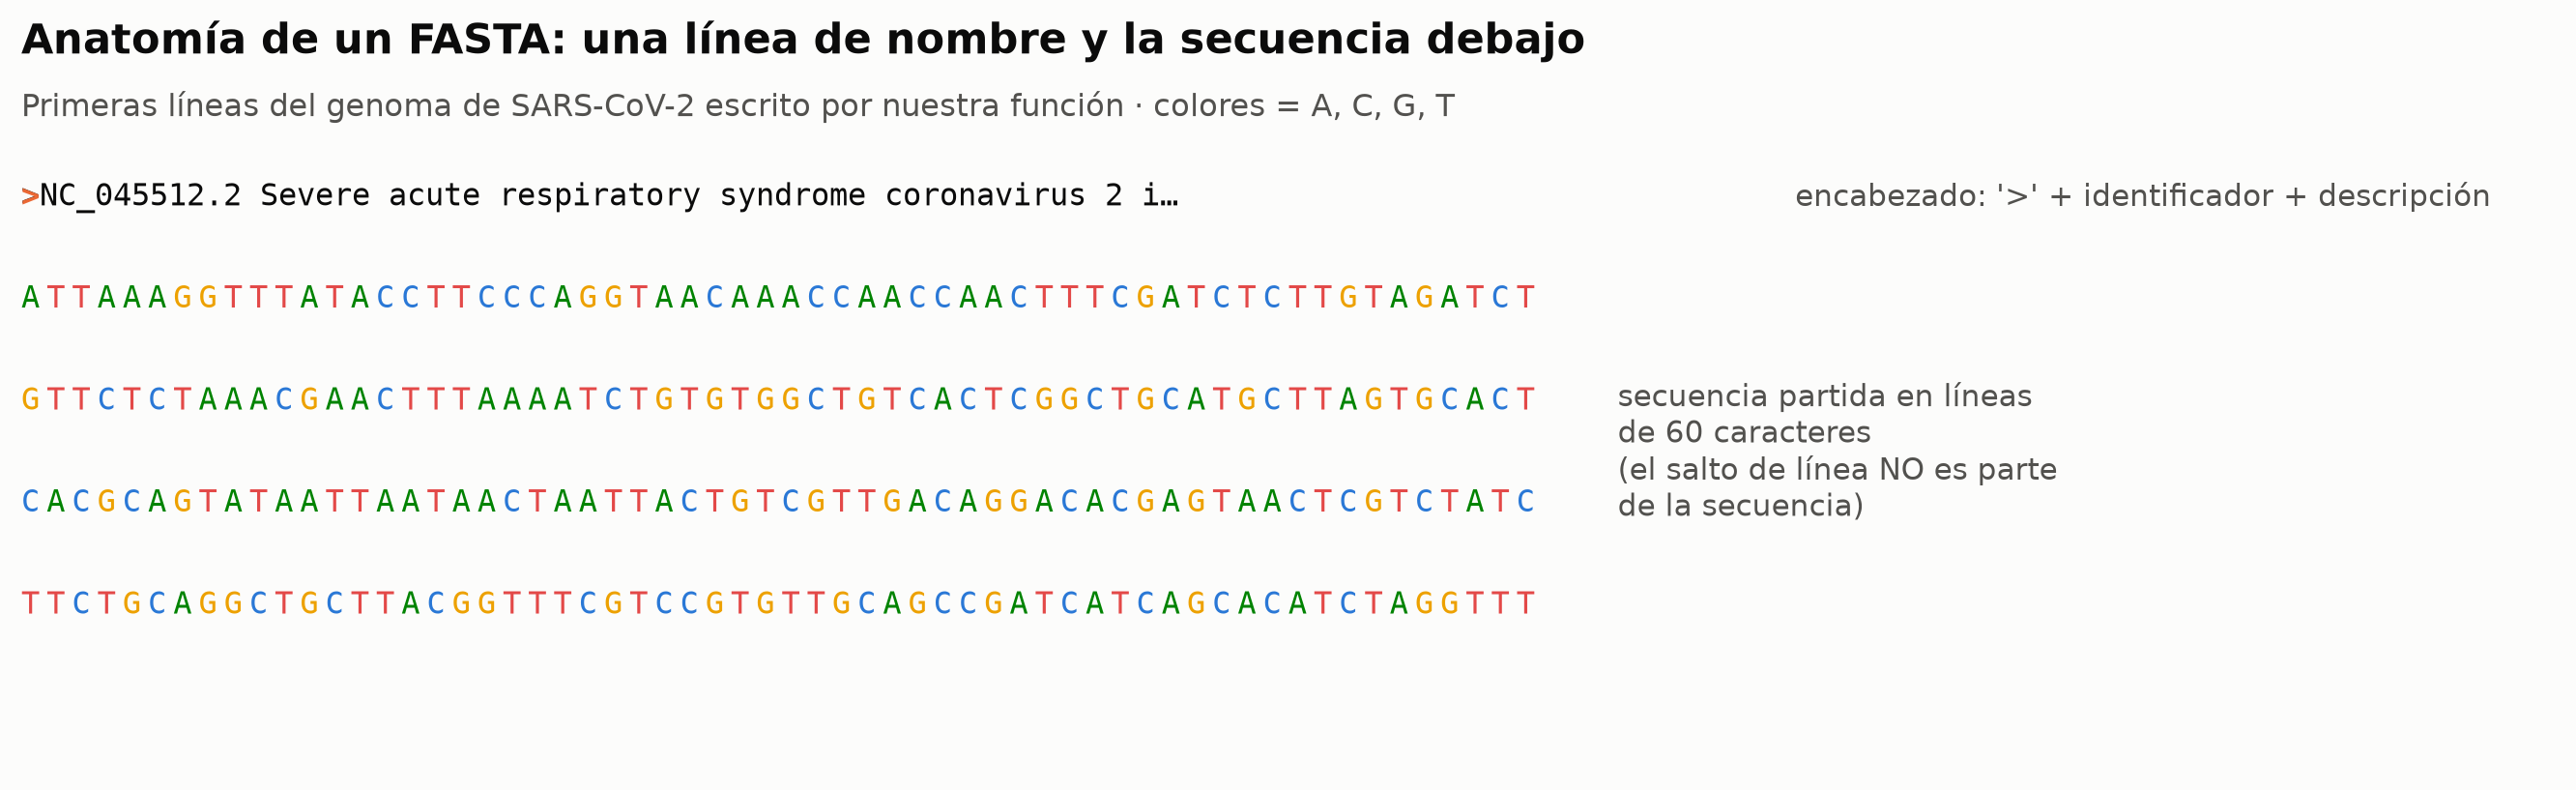

In [6]:
# Anatomía visual de un archivo FASTA
lines = open("sars.fasta").read().splitlines()[:5]
fig, ax = plt.subplots(figsize=(12, 3.6))
ax.set_xlim(0, 100); ax.set_ylim(-0.6, 5.6); ax.axis("off")
cw = 1.0                                              # ancho de cada carácter (unidades de datos)
hdr = lines[0][:62] + "…"
ax.text(0, 5, hdr, family="DejaVu Sans Mono", fontsize=10.5, color=ec.INK, va="center")
ax.text(0, 5, ">", family="DejaVu Sans Mono", fontsize=10.5, color=ec.ORANGE, va="center", fontweight="bold")
for r, line in enumerate(lines[1:], start=1):
    y = 5 - r
    for j, b in enumerate(line):
        ax.text(j * cw, y, b, family="DejaVu Sans Mono", fontsize=10.5, color=ec.NUC_COLORS.get(b, ec.MUTED),
                va="center")
ax.annotate("encabezado: '>' + identificador + descripción", xy=(64, 5), xytext=(70, 5), va="center",
            fontsize=10, color=ec.INK_2, arrowprops=dict(arrowstyle="-", color=ec.MUTED))
ax.annotate("", xy=(61.5, 4.1), xytext=(61.5, 0.9), arrowprops=dict(arrowstyle="-", color=ec.MUTED))
ax.text(63, 2.5, "secuencia partida en líneas\nde 60 caracteres\n(el salto de línea NO es parte\nde la secuencia)",
        fontsize=10, color=ec.INK_2, va="center")
ec.title(ax, "Anatomía de un FASTA: una línea de nombre y la secuencia debajo",
         "Primeras líneas del genoma de SARS-CoV-2 escrito por nuestra función · colores = A, C, G, T")
plt.show()

✅ **Compruebe su comprensión.** (1) ¿Qué identificador vería una herramienta que corta en el primer espacio para
el encabezado `>NC_045512.2 Severe acute respiratory…`? (2) Si el genoma mide 29 903 nt y usamos líneas de 60, ¿cuántas
líneas de secuencia tendrá el archivo? *(Respuestas: `NC_045512.2`; ⌈29 903/60⌉ = 499 líneas.)*

## 3. FASTQ: la secuencia con su "nivel de confianza"

Un secuenciador no sólo dice **qué** base leyó, sino **cuán seguro está**. Es como un testigo en un juicio que,
además de declarar "el auto era rojo", agrega "estoy 99.9 % seguro". Esa segunda información es valiosísima: nos
permite descartar lecturas dudosas y, más adelante, distinguir una mutación real de un error de la máquina.

El formato FASTQ guarda cada lectura en **exactamente cuatro líneas**:

```
@read_0001 pos=12345        ← 1. "@" + nombre de la lectura
ACGTTGCA...                 ← 2. la secuencia leída
+                           ← 3. separador (a veces repite el nombre)
IIIIHHG?...                 ← 4. un carácter de CALIDAD por cada base
```

### La escala Phred

La calidad no se guarda como probabilidad (0.001) sino en una escala **logarítmica** inventada para el programa
*phred* del Proyecto Genoma Humano (Ewing y Green, 1998):

$$
\boxed{\;Q \;=\; -10\,\log_{10} P\;}
\qquad\Longleftrightarrow\qquad
P \;=\; 10^{-Q/10}
$$

| Símbolo | Significado |
|---|---|
| $P$ | probabilidad de que la base leída sea **incorrecta** |
| $Q$ | calidad Phred: un número entero, más alto = más confiable |
| $\log_{10}$ | logaritmo en base 10: cada 10 puntos de $Q$ la probabilidad de error se divide entre 10 |

**Ejemplos a mano.** Una base con $Q = 20$ tiene $P = 10^{-20/10} = 10^{-2} = 0.01$: se equivoca 1 vez de cada 100.
Con $Q = 30$: $P = 10^{-3}$, 1 en 1 000. Y si la máquina dice $P = 0.05$, entonces
$Q = -10 \log_{10}(0.05) = -10 \times (-1.30) = 13$.

| $Q$ | $P$(error) | Se equivoca… | Exactitud |
|---|---|---|---|
| 10 | 0.1 | 1 en 10 | 90 % |
| 20 | 0.01 | 1 en 100 | 99 % |
| 30 | 0.001 | 1 en 1 000 | 99.9 % |
| 40 | 0.0001 | 1 en 10 000 | 99.99 % |

¿Por qué una escala logarítmica? Porque lo que nos importa es el **orden de magnitud** del error, igual que en la
escala de decibeles del sonido o en el pH: pasar de 1 en 100 a 1 en 1 000 es un salto enorme, y la escala Phred lo
convierte en una simple suma de 10 puntos.

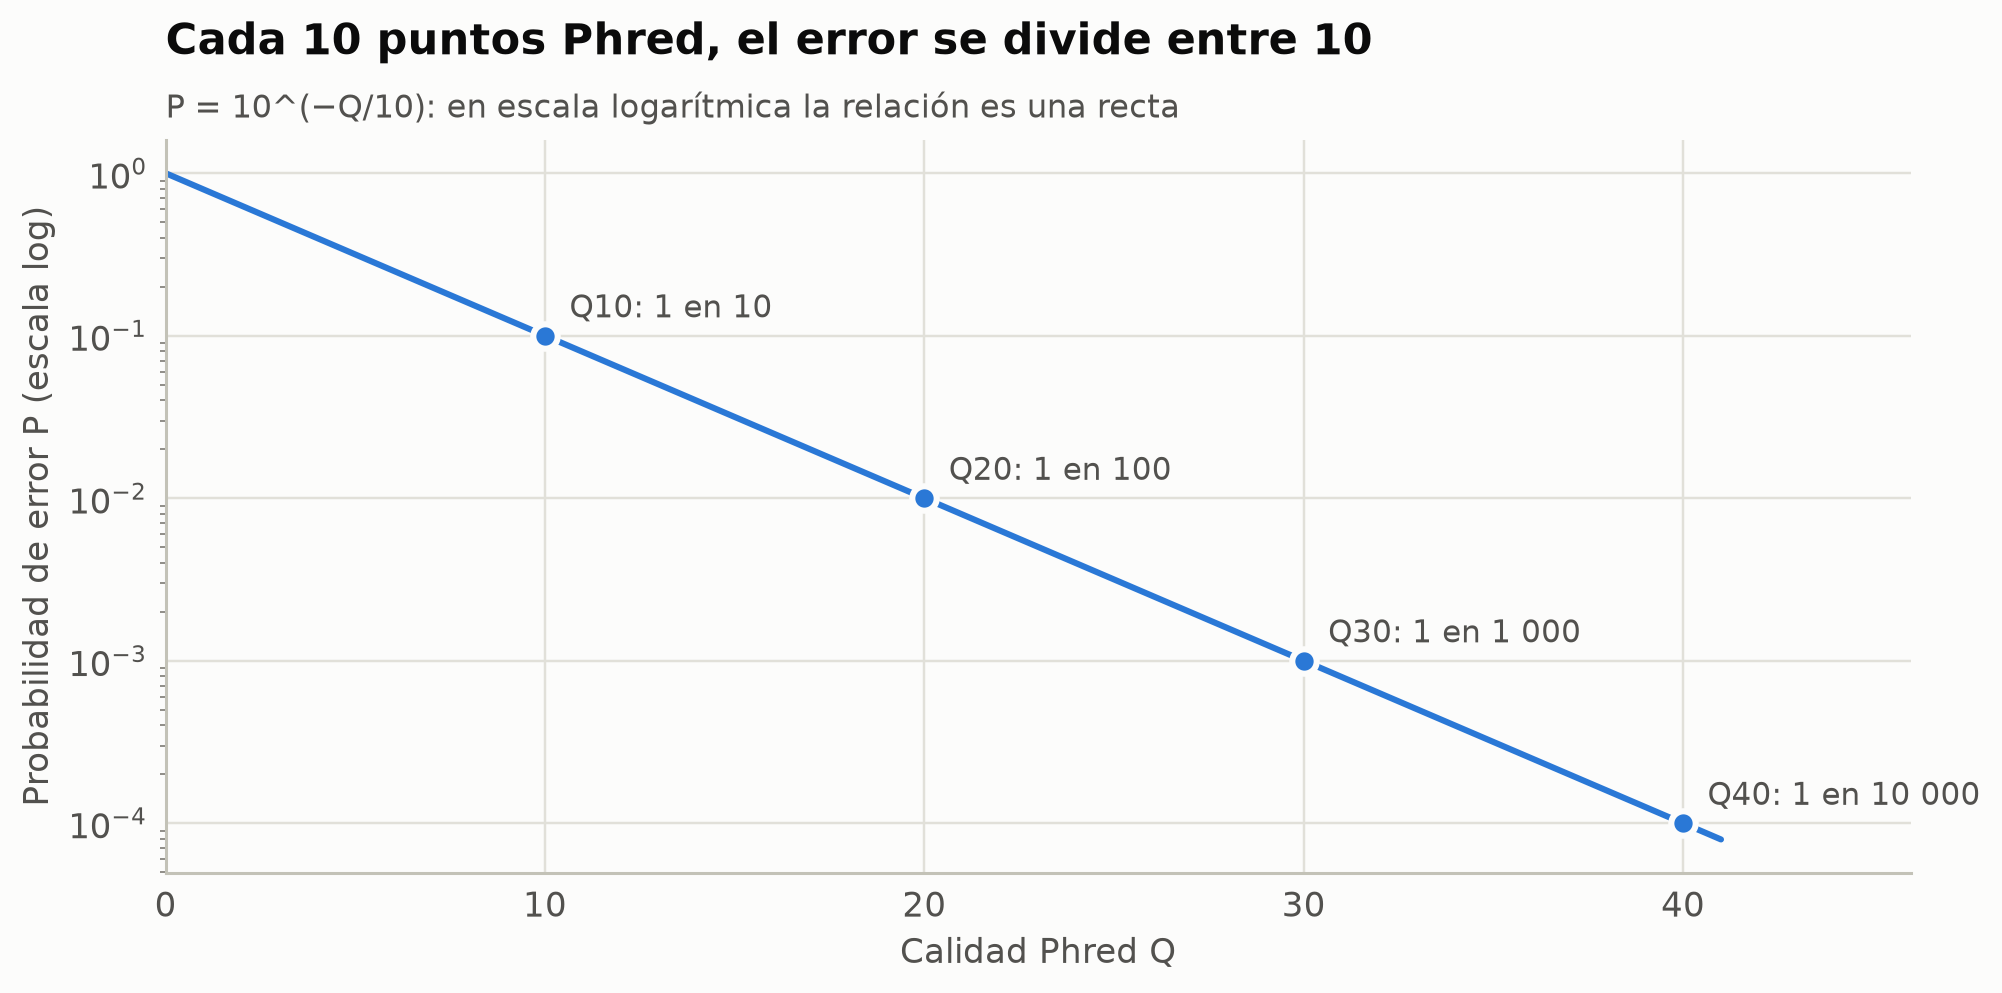

In [7]:
q = np.arange(0, 42)
p = 10 ** (-q / 10)
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.semilogy(q, p, color=ec.BLUE)
for qq, lab in [(10, "1 en 10"), (20, "1 en 100"), (30, "1 en 1 000"), (40, "1 en 10 000")]:
    ax.plot(qq, 10 ** (-qq / 10), "o", color=ec.BLUE, markersize=8, markeredgecolor=ec.SURFACE, markeredgewidth=2)
    ax.annotate(f"Q{qq}: {lab}", (qq, 10 ** (-qq / 10)), xytext=(8, 6), textcoords="offset points",
                fontsize=10, color=ec.INK_2)
ax.set_xlabel("Calidad Phred Q"); ax.set_ylabel("Probabilidad de error P (escala log)")
ax.set_xlim(0, 46)
ax.grid(True, axis="both", which="major")
ec.title(ax, "Cada 10 puntos Phred, el error se divide entre 10",
         "P = 10^(−Q/10): en escala logarítmica la relación es una recta")
plt.show()

### De número a carácter: la codificación ASCII + 33

Para que la línea de calidad tenga **la misma longitud** que la secuencia (un carácter por base), cada $Q$ se
convierte en **un solo carácter** del alfabeto ASCII. La computadora guarda cada carácter como un número (su código
ASCII: `A` = 65, `I` = 73…). Los primeros 32 códigos son invisibles (tabulador, salto de línea…), así que se suma
un **desplazamiento de 33** para caer en caracteres imprimibles:

$$
\text{carácter} \;=\; \mathrm{chr}(Q + 33)
\qquad\qquad
Q \;=\; \mathrm{ord}(\text{carácter}) - 33
$$

**Decodificación a mano.** La cadena de calidad `II?5+#`:

| Carácter | `I` | `I` | `?` | `5` | `+` | `#` |
|---|---|---|---|---|---|---|
| ASCII | 73 | 73 | 63 | 53 | 43 | 35 |
| $Q$ = ASCII − 33 | 40 | 40 | 30 | 20 | 10 | 2 |
| $P$(error) | 0.0001 | 0.0001 | 0.001 | 0.01 | 0.1 | 0.63 |

Por eso en archivos FASTQ modernos (Illumina 1.8+, "Phred+33") abundan las `F`, `:` y `,` (el NovaSeq agrupa las
calidades en pocos valores) o las `I` (Q40). *Históricamente existió "Phred+64"; si ve muchas letras minúsculas en la
calidad, sospeche de un archivo antiguo.*

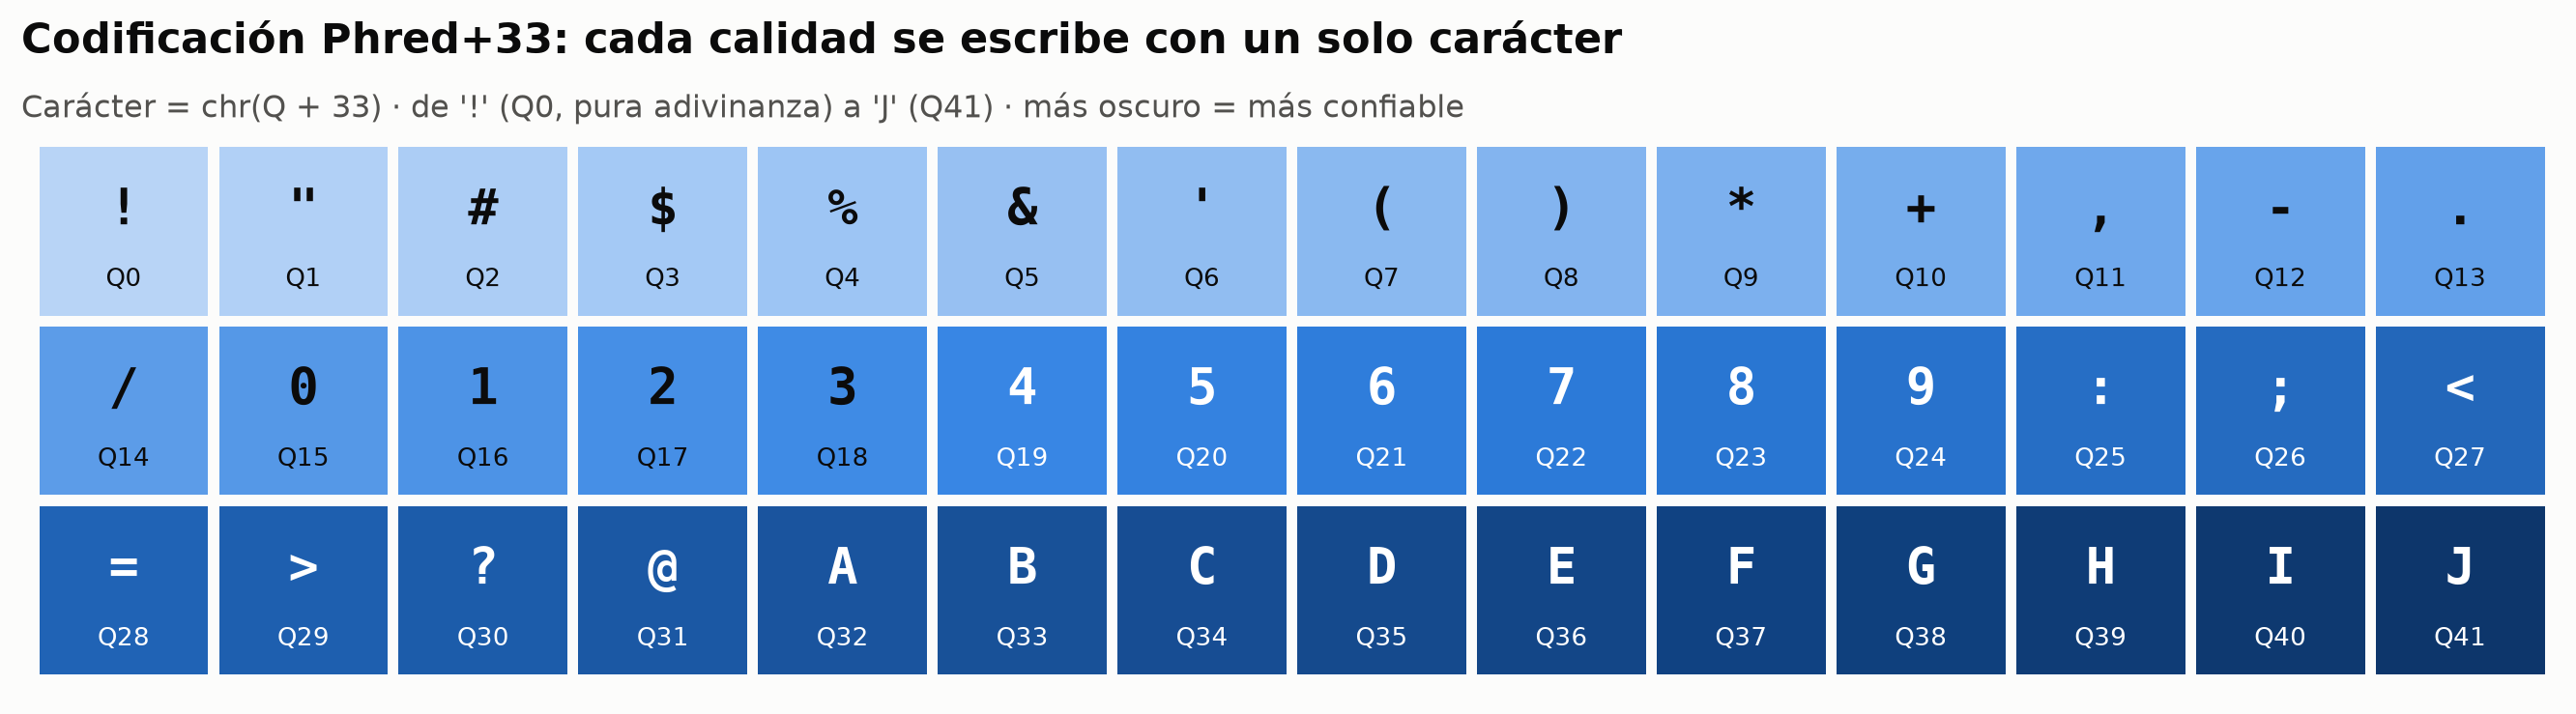

Decodificando 'II?5+#': [40, 40, 30, 20, 10, 2]


In [8]:
fig, ax = plt.subplots(figsize=(12, 4.6))
ncol = 14
for qv in range(42):
    r, c = divmod(qv, ncol)
    color = ec.CMAP_SEQ(0.08 + 0.92 * qv / 41)
    ax.add_patch(plt.Rectangle((c, -r), 0.94, 0.94, color=color, lw=0))
    txt = "white" if qv > 18 else ec.INK
    ax.text(c + 0.47, -r + 0.58, chr(qv + 33), ha="center", va="center", fontsize=17, fontweight="bold",
            family="DejaVu Sans Mono", color=txt)
    ax.text(c + 0.47, -r + 0.2, f"Q{qv}", ha="center", va="center", fontsize=8.5, color=txt)
ax.set_xlim(-0.1, ncol); ax.set_ylim(-2.1, 1.0); ax.axis("off"); ax.set_aspect("equal")
ec.title(ax, "Codificación Phred+33: cada calidad se escribe con un solo carácter",
         "Carácter = chr(Q + 33) · de '!' (Q0, pura adivinanza) a 'J' (Q41) · más oscuro = más confiable")
plt.show()

def phred_to_char(qv): return chr(qv + 33)
def char_to_phred(ch): return ord(ch) - 33
print("Decodificando 'II?5+#':", [char_to_phred(ch) for ch in "II?5+#"])

## 4. 🧪 Experimento: simular una corrida de secuenciación y medir su calidad

Vamos a construir nuestro propio "secuenciador Illumina de juguete" para entender de dónde salen los FASTQ. En un
Illumina, millones de fragmentos de ADN se amplifican en **clusters** sobre una placa de vidrio; en cada **ciclo** se
añade un nucleótido fluorescente, una cámara fotografía la placa y el color de cada cluster dice qué base se leyó.
Ciclo a ciclo, algunas moléculas del cluster se "desfasan" (se adelantan o atrasan), la señal se vuelve más
borrosa y **la calidad cae hacia el final de la lectura**.

Nuestro modelo, de manera simplificada:

1. Elegimos al azar el inicio de cada lectura de 150 nt en el genoma de SARS-CoV-2.
2. Asignamos a cada posición una calidad que **decae** con el ciclo, más un "humor" propio de cada cluster (hay
   clusters mejores y peores) y ruido.
3. **Introducimos errores** usando exactamente la probabilidad que dice su calidad: una base con $Q = 20$ se cambia
   con probabilidad 0.01.

🤔 **Antes de ejecutar, prediga.** Si la calidad media empieza en ~37 y termina en ~25, ¿dónde se concentrarán los
errores: al principio o al final de las lecturas? ¿Aproximadamente cuántos errores tendrá en promedio una lectura
de 150 nt?

In [9]:
rng = np.random.default_rng(21)
READ_LEN, N_READS = 150, 4_000
BASES = np.array(list("ACGT"))

def simulate_quality(n, length, rng):
    """Matriz n × length de calidades Phred con caída hacia el final (modelo de juguete de Illumina)."""
    pos = np.arange(length)
    mean_q = 37 - 12 * (pos / length) ** 2                # la señal se degrada ciclo a ciclo
    cluster_effect = rng.normal(0, 2.5, size=(n, 1))       # clusters mejores y peores
    noise = rng.normal(0, 2.0, size=(n, length))
    qual = mean_q + cluster_effect + noise
    bad = rng.random(n) < 0.06                              # 6 % de clusters con "cola" defectuosa
    qual[bad] -= np.clip((pos - 100) * 0.4, 0, None)
    return np.clip(np.round(qual), 2, 41).astype(int)

def simulate_reads(ref, n, length, rng):
    starts = rng.integers(0, len(ref) - length, size=n)
    true = np.array([list(ref[s:s + length]) for s in starts])
    qual = simulate_quality(n, length, rng)
    p_err = 10 ** (-qual / 10)
    is_err = rng.random(qual.shape) < p_err                 # el error ocurre con la probabilidad Phred
    called = true.copy()
    for i, j in zip(*np.nonzero(is_err)):                   # cambiamos por otra base al azar
        called[i, j] = rng.choice([b for b in "ACGT" if b != true[i, j]])
    return starts, called, qual, is_err

starts, reads, quals, is_err = simulate_reads(ref, N_READS, READ_LEN, rng)

with open("reads.fastq", "w") as fh:
    for i in range(N_READS):
        fh.write(f"@read_{i:04d} pos={starts[i] + 1}\n{''.join(reads[i])}\n+\n")
        fh.write("".join(phred_to_char(qv) for qv in quals[i]) + "\n")

print("".join(open("reads.fastq").readlines()[:4]))
print(f"Errores introducidos: {is_err.sum():,} en {is_err.size:,} bases ({is_err.mean():.3%})")
print(f"Errores por lectura: media = {is_err.sum(1).mean():.2f}")

@read_0000 pos=8968
ACTTATAGAGTACACTGACTTTGCAACATCAGCTTGTGTTTTGGCTGCTGAATGTACAATTTTTAAAGATGCTTCTGGTAAGCCAGTACCATATTGTTATGATACCAATGTACTAGAAGGTTCTGTTGCTTATGAAAGTTTACGCCCTGA
+
JIHIJJJJHHJJJJJJJJJGJJJJJJJJGJJJJIIJIJJHIHJIJHJJFIJJIJGHJJHHHJJHGFFJGCJJGJIEGGHFCGJCECEFDGCEGFIDHECEGEEFAEFDFEABCCFE@DGFCA>CCAAEBDB?CBC@@ADBB?CABB>?@@

Errores introducidos: 1,219 en 600,000 bases (0.203%)
Errores por lectura: media = 0.30


### Un lector de FASTQ desde cero

Como cada registro ocupa exactamente 4 líneas, el lector es aún más simple que el de FASTA: leemos de 4 en 4 y
**verificamos** la estructura (que la línea 1 empiece con `@`, la 3 con `+` y que secuencia y calidad midan lo mismo).
Estas verificaciones atrapan archivos truncados o corruptos, un problema real cuando se descargan archivos de
decenas de gigabytes.

In [10]:
def parse_fastq(path):
    """Genera (nombre, secuencia, calidades numpy) para cada registro de un FASTQ."""
    with open(path) as fh:
        while True:
            name = fh.readline().rstrip()
            if not name:
                break
            seq, plus, qual = fh.readline().rstrip(), fh.readline().rstrip(), fh.readline().rstrip()
            assert name.startswith("@") and plus.startswith("+"), f"registro mal formado: {name}"
            assert len(seq) == len(qual), f"secuencia y calidad de distinta longitud: {name}"
            yield name[1:], seq, np.frombuffer(qual.encode(), dtype=np.uint8).astype(int) - 33

parsed = list(parse_fastq("reads.fastq"))
Q = np.vstack([qv for _, _, qv in parsed])
print(len(parsed), "lecturas leídas · matriz de calidades:", Q.shape, "· ¿igual a la simulada?", (Q == quals).all())

4000 lecturas leídas · matriz de calidades: (4000, 150) · ¿igual a la simulada? True


### El gráfico más famoso del control de calidad

El programa **FastQC** (Babraham Institute) es lo primero que se corre sobre cualquier FASTQ. Su gráfico estrella es
la **calidad por posición**: para cada ciclo, una "caja" que resume las calidades de todas las lecturas en ese
ciclo. El fondo se pinta en tres zonas (buena ≥ 28, aceptable 20–28, mala < 20). Construyámoslo nosotros mismos:

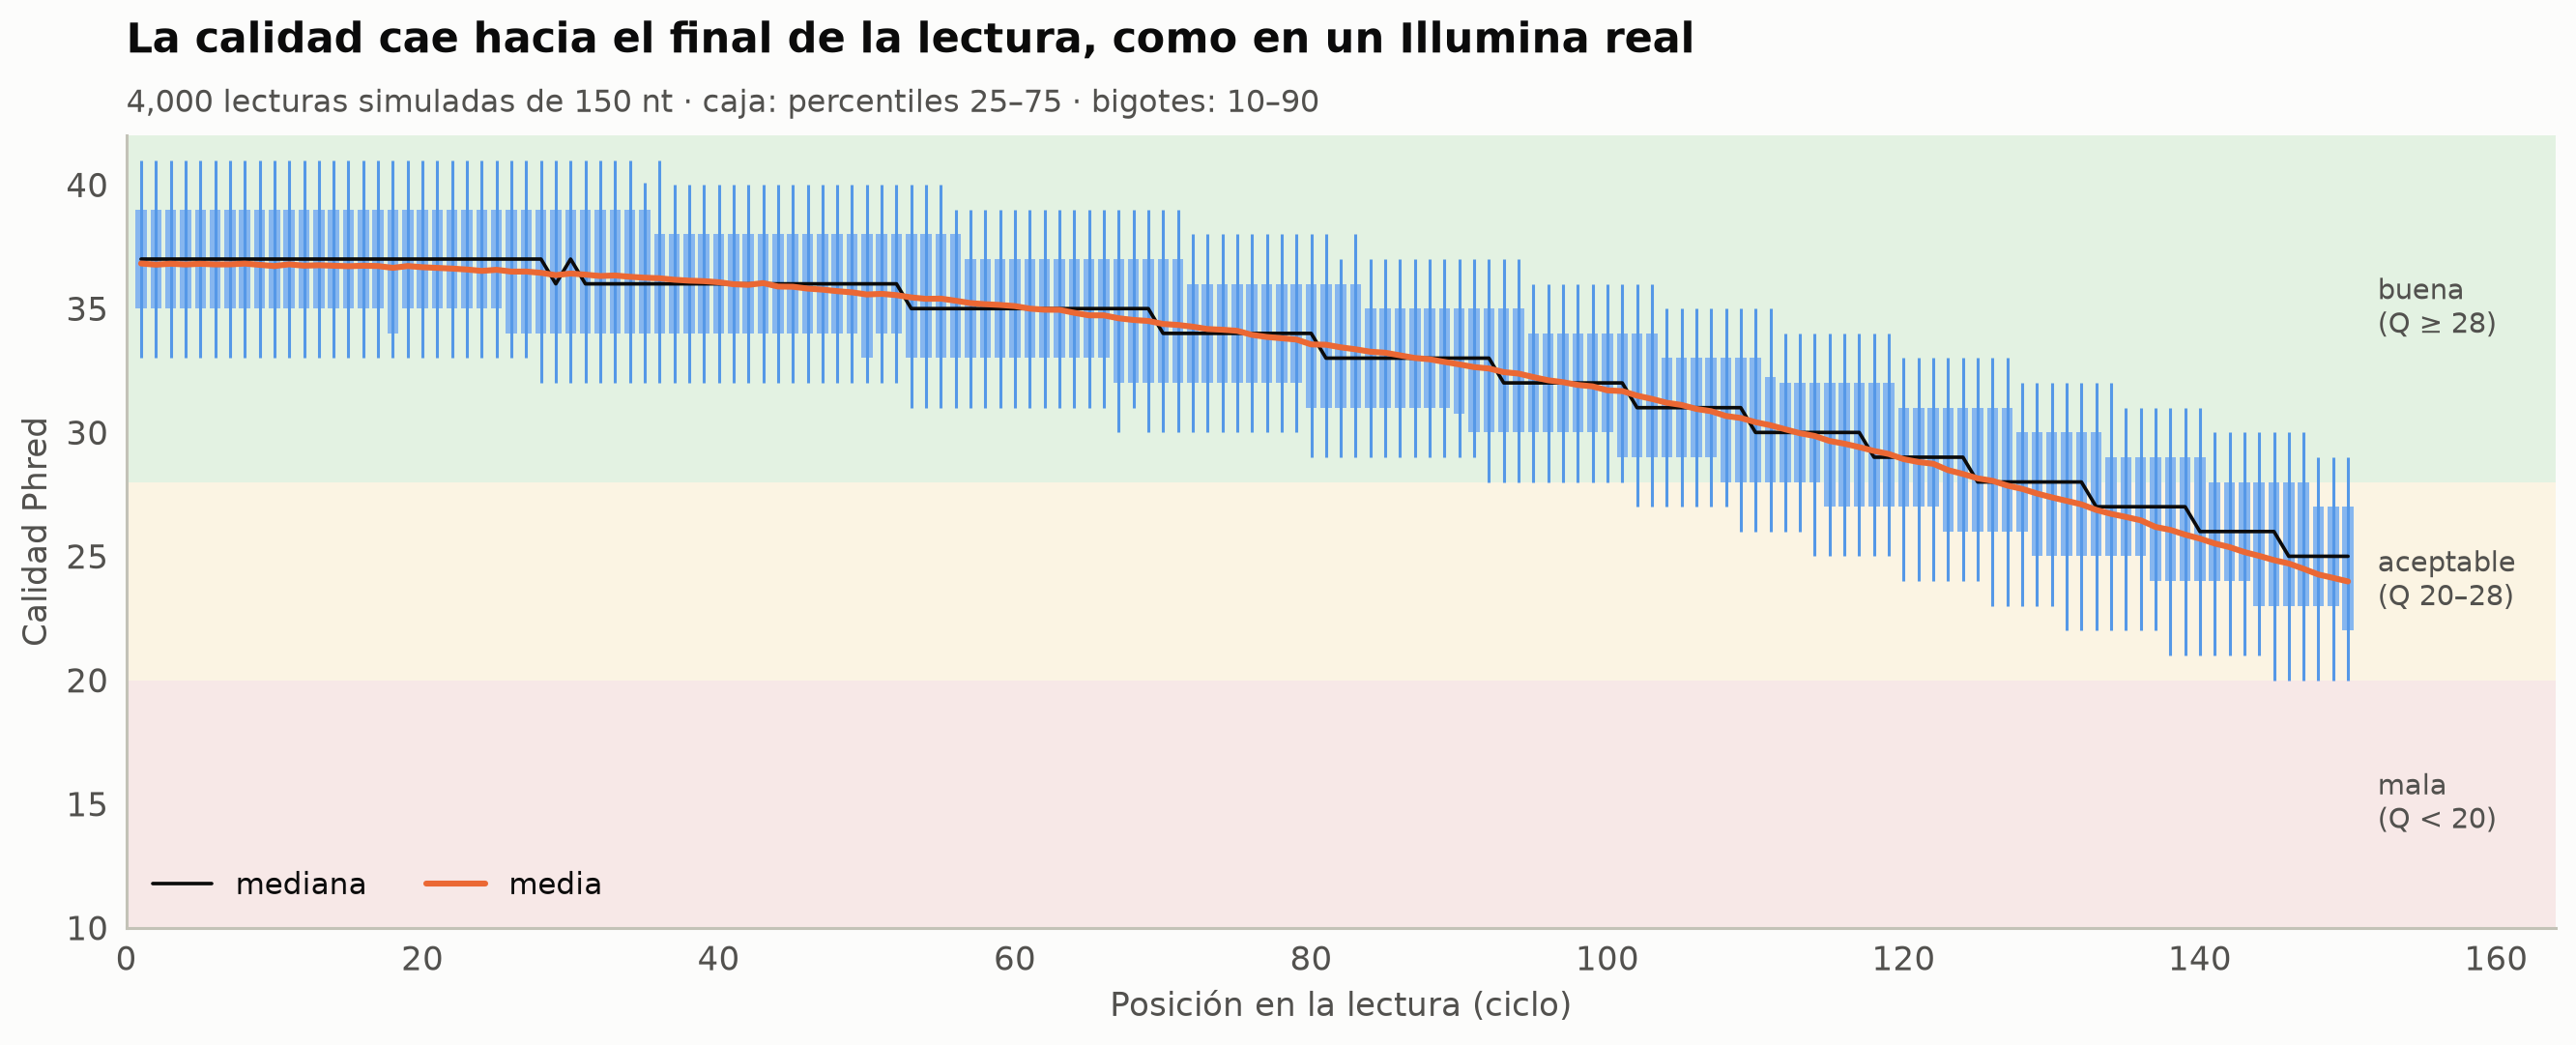

In [11]:
pct = np.percentile(Q, [10, 25, 50, 75, 90], axis=0)
x = np.arange(1, READ_LEN + 1)

fig, ax = plt.subplots(figsize=(12, 4.8))
for lo, hi, key, lab in [(28, 42, "good", "buena"), (20, 28, "warning", "aceptable"), (10, 20, "critical", "mala")]:
    ax.axhspan(lo, hi, color=ec.STATUS[key], alpha=0.10, lw=0, zorder=0)
    ax.text(READ_LEN + 2, (lo + hi) / 2, f"{lab}\n(Q < {hi})" if lo == 10 else f"{lab}\n(Q {lo}–{hi})" if hi < 42 else f"{lab}\n(Q ≥ {lo})",
            va="center", fontsize=9.5, color=ec.INK_2)
ax.vlines(x, pct[0], pct[4], color=ec.SEQ_BLUE[5], lw=1)                  # bigotes: percentiles 10–90
ax.bar(x, pct[3] - pct[1], bottom=pct[1], width=0.75, color=ec.SEQ_BLUE[3], lw=0)   # caja: 25–75
ax.plot(x, pct[2], color=ec.INK, lw=1.2, label="mediana")
ax.plot(x, Q.mean(0), color=ec.ORANGE, lw=2, label="media")
ax.set_xlim(0, READ_LEN + 14); ax.set_ylim(10, 42)
ax.set_xlabel("Posición en la lectura (ciclo)"); ax.set_ylabel("Calidad Phred")
ax.legend(loc="lower left", ncol=2)
ax.grid(False)
ec.title(ax, "La calidad cae hacia el final de la lectura, como en un Illumina real",
         f"{N_READS:,} lecturas simuladas de 150 nt · caja: percentiles 25–75 · bigotes: 10–90")
plt.show()

🔎 **Qué observamos.** Las cajas empiezan altas (Q ≈ 37) y bajan de forma curva; hacia el final aparecen bigotes
largos hacia abajo: son los clusters "defectuosos". En un análisis real esto justifica **recortar** (*trimming*) las
colas de baja calidad antes de alinear, algo que haremos en el Módulo 6.

### Los errores esperados de una lectura

¿Cuántos errores **esperamos** en una lectura concreta? Como cada base aporta su propia probabilidad de error, basta
con **sumarlas** (la esperanza de una suma es la suma de las esperanzas):

$$
\mathrm{EE} \;=\; \sum_{j=1}^{L} P_j \;=\; \sum_{j=1}^{L} 10^{-Q_j/10}
$$

| Símbolo | Significado |
|---|---|
| $\mathrm{EE}$ | errores esperados (*expected errors*) de la lectura |
| $L$ | longitud de la lectura |
| $Q_j$ | calidad Phred de la base $j$ |
| $P_j$ | probabilidad de error de la base $j$ |

**Ejemplo a mano.** Una lectura de 5 bases con calidades $(40, 30, 20, 20, 10)$:
$\mathrm{EE} = 0.0001 + 0.001 + 0.01 + 0.01 + 0.1 = 0.1211$. ¡Una sola base mala (Q10) aporta el 83 % del total!

El criterio "descartar lecturas con EE > 1" (Edgar y Flyvbjerg, 2015) es mucho más informativo que la calidad
promedio, porque el promedio de Phred esconde las bases malas: el promedio de $(40, 40, 40, 40, 2)$ es 32.4, que
"se ve bien", pero esa lectura tiene $\mathrm{EE} \approx 0.63$.

Como en nuestra simulación **sabemos** qué bases están equivocadas, podemos hacer algo imposible con datos reales:
verificar que los errores esperados predicen los observados.

Ejemplo a mano: 0.1211


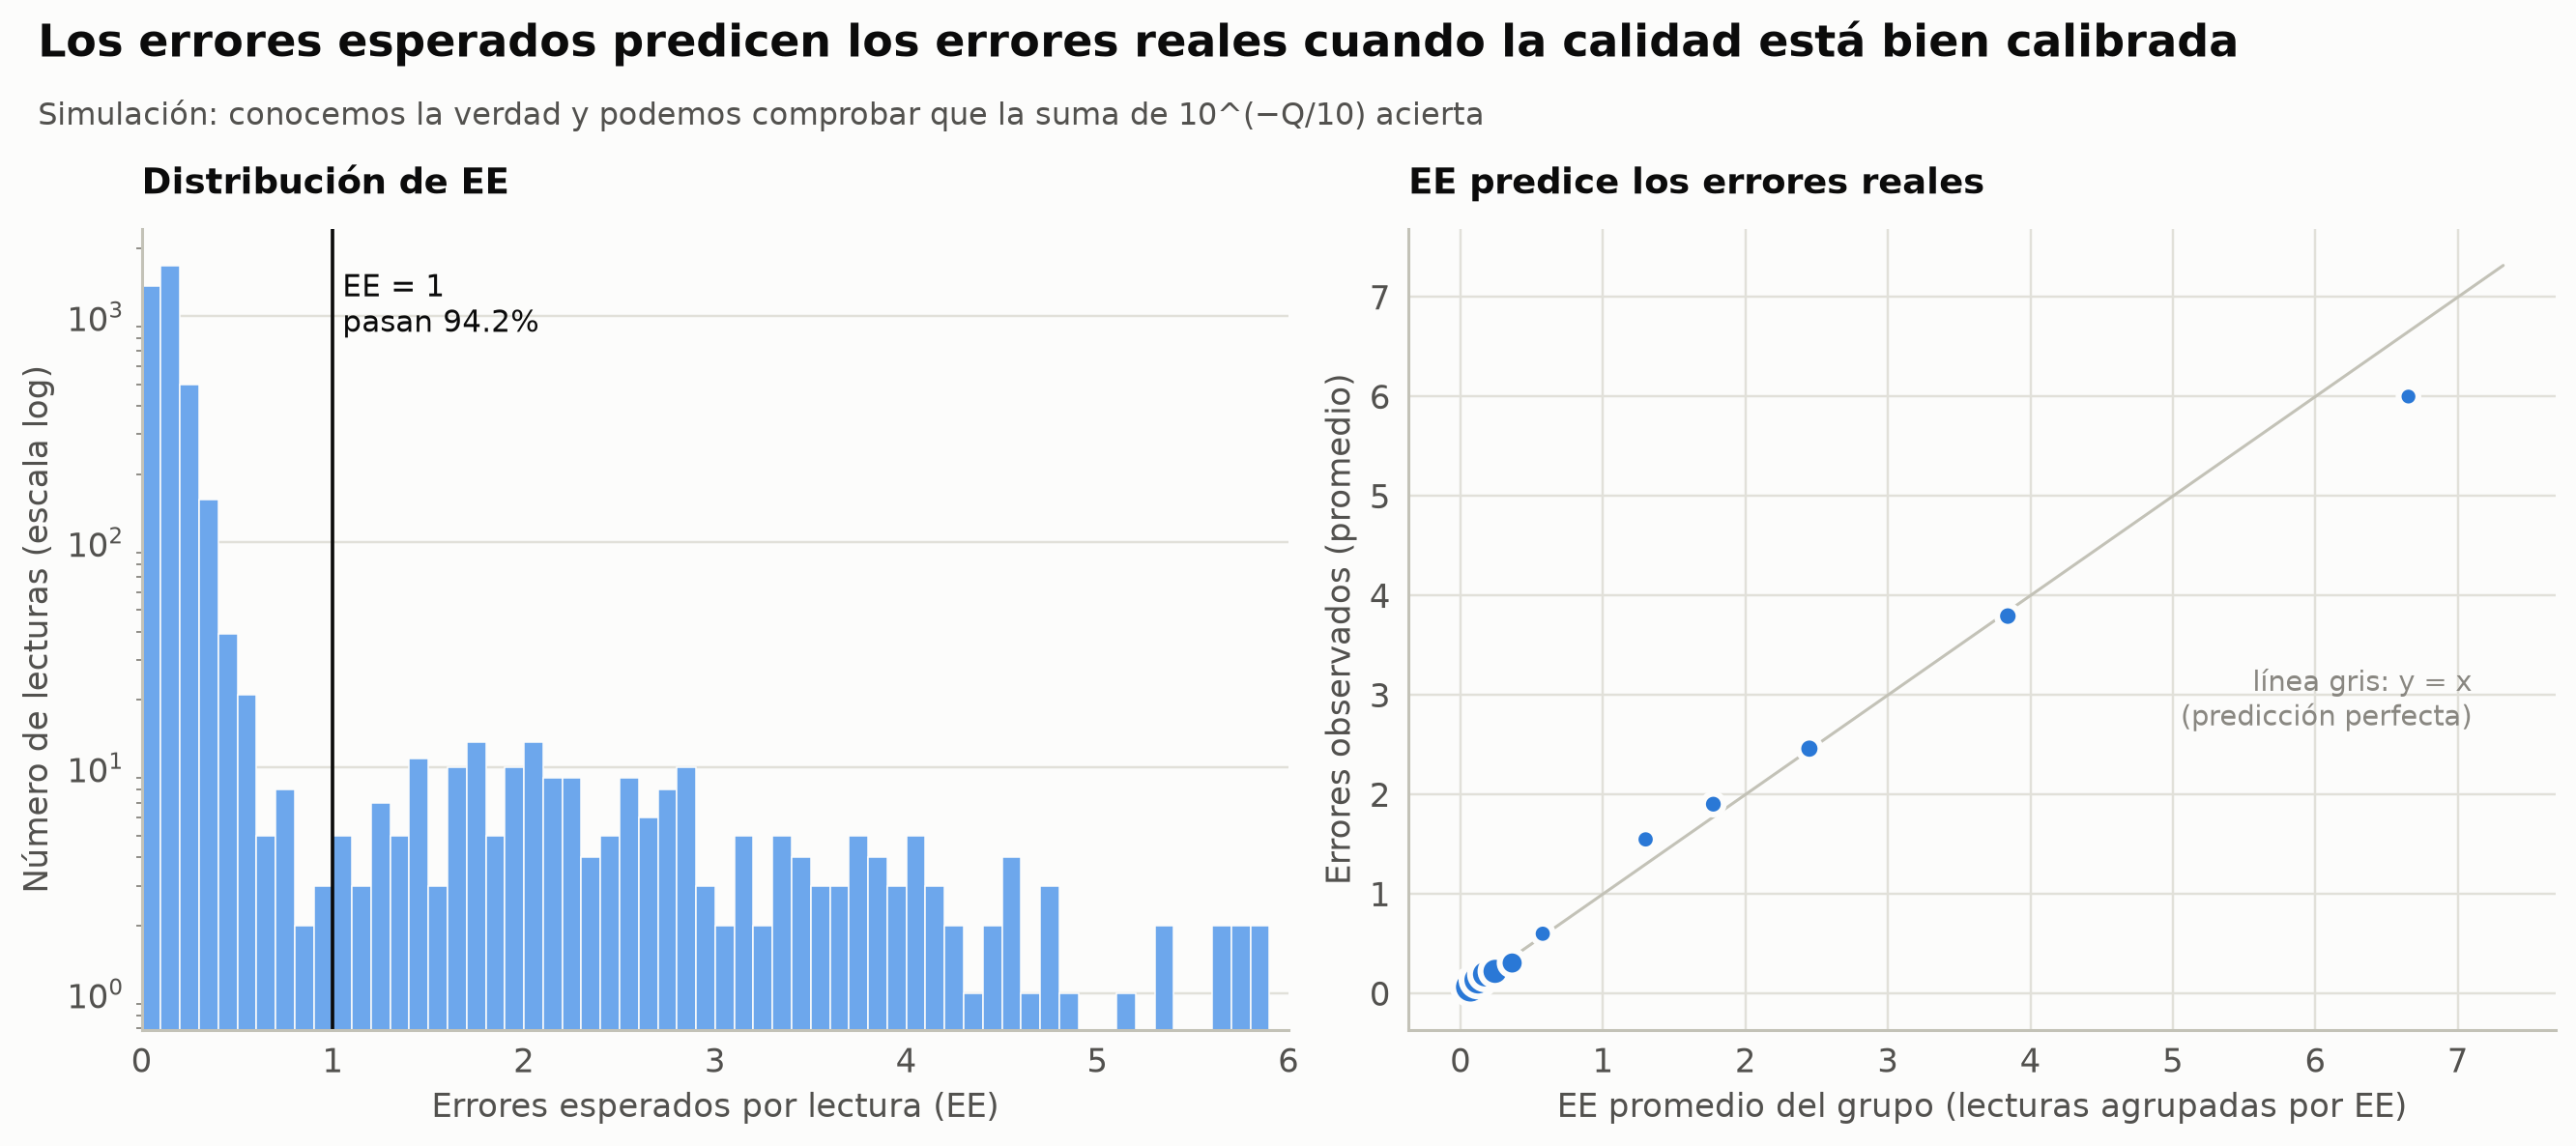

In [12]:
EE = (10 ** (-Q / 10)).sum(axis=1)
observed = is_err.sum(axis=1)
print(f"Ejemplo a mano: {(10 ** (-np.array([40, 30, 20, 20, 10]) / 10)).sum():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
ax = axes[0]
ax.hist(EE, bins=np.linspace(0, 6, 61), color=ec.SEQ_BLUE[4], edgecolor=ec.SURFACE, linewidth=0.5)
ax.axvline(1, color=ec.INK, lw=1.2)
ax.text(1.05, ax.get_ylim()[1] * 0.9, f"EE = 1\npasan {np.mean(EE <= 1):.1%}", fontsize=10, color=ec.INK, va="top")
ax.set_xlabel("Errores esperados por lectura (EE)"); ax.set_ylabel("Número de lecturas (escala log)")
ax.set_yscale("log"); ax.set_xlim(0, 6)
ax.set_title("Distribución de EE", fontsize=12)

ax = axes[1]
edges = np.array([0, 0.1, 0.15, 0.2, 0.3, 0.5, 0.75, 1, 1.5, 2, 3, 5, 20])
idx = np.digitize(EE, edges) - 1
groups = [k for k in range(len(edges) - 1) if (idx == k).sum() >= 10]      # sólo grupos con ≥ 10 lecturas
mean_ee = np.array([EE[idx == k].mean() for k in groups])
mean_obs = np.array([observed[idx == k].mean() for k in groups])
counts = np.array([(idx == k).sum() for k in groups])
lim = max(mean_ee.max(), mean_obs.max()) * 1.1
ax.plot([0, lim], [0, lim], color=ec.BASELINE, lw=1)
ax.text(lim * 0.97, lim * 0.45, "línea gris: y = x\n(predicción perfecta)", color=ec.MUTED, ha="right", va="top", fontsize=9.5)
ax.scatter(mean_ee, mean_obs, s=30 + 3 * np.sqrt(counts), color=ec.BLUE, edgecolor=ec.SURFACE, linewidth=2, zorder=3)
ax.set_xlabel("EE promedio del grupo (lecturas agrupadas por EE)"); ax.set_ylabel("Errores observados (promedio)")
ax.set_title("EE predice los errores reales", fontsize=12)
ax.grid(True, axis="both")
ec.fig_title(fig, "Los errores esperados predicen los errores reales cuando la calidad está bien calibrada",
             "Simulación: conocemos la verdad y podemos comprobar que la suma de 10^(−Q/10) acierta")
plt.show()

🔎 **Qué observamos.** Los puntos caen sobre la diagonal: una lectura con EE = 2 tiene, en promedio, 2 errores. En
datos reales esto sólo es cierto si el secuenciador está **bien calibrado**; herramientas como GATK *BQSR*
recalibran las calidades justamente porque a veces no lo están.

### 🔍 Explorador interactivo de calidades

Cada fila es una lectura y cada columna un ciclo. Pase el cursor: verá la base, el carácter ASCII guardado en el
archivo, la calidad Phred y la probabilidad de error. Las cruces marcan los **errores reales** que introdujimos:
fíjese en que se concentran en las zonas claras (baja calidad).

Resorting to unclean kill browser.


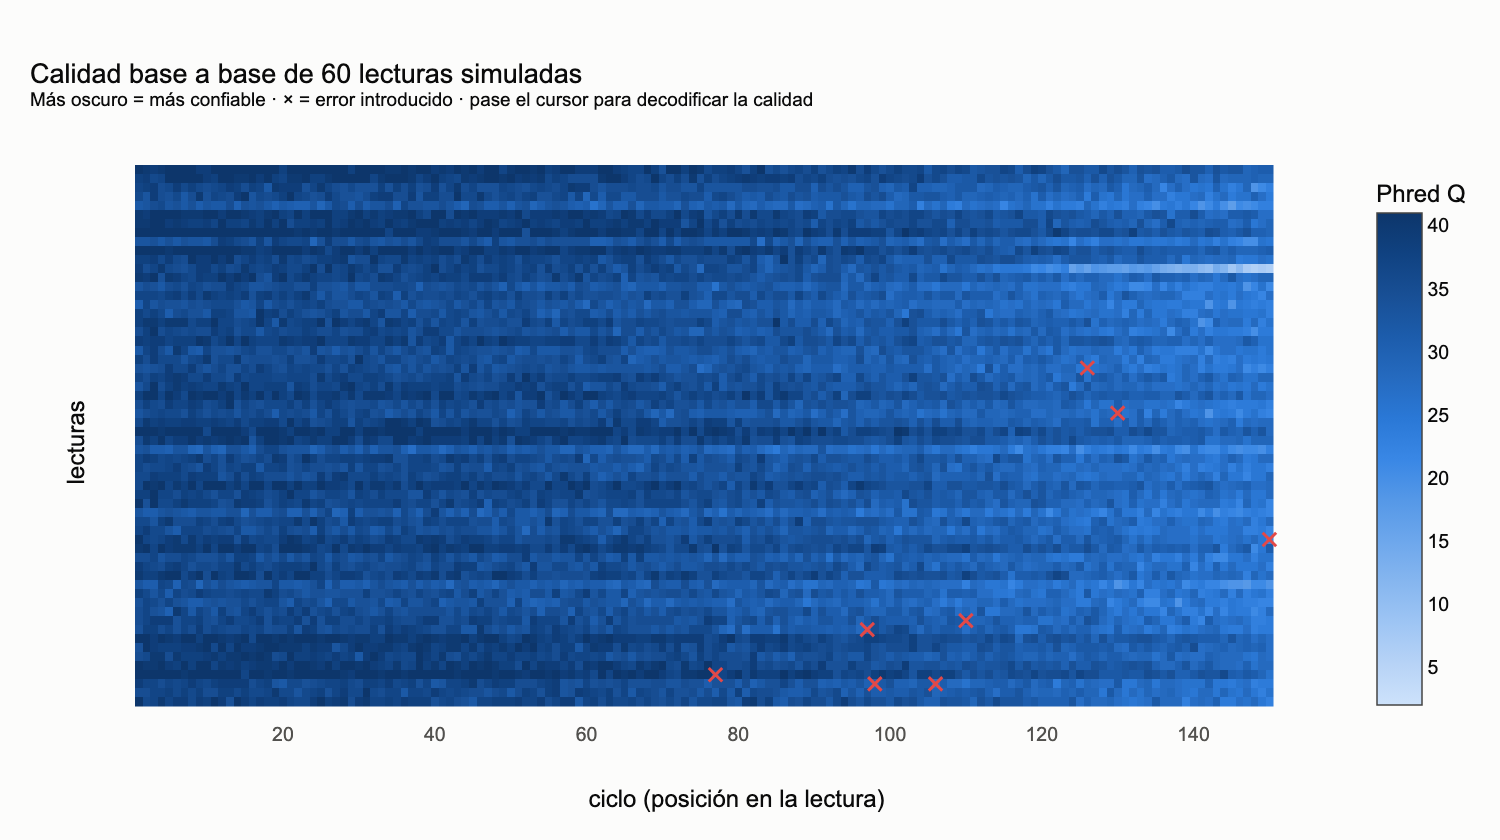

In [13]:
n_show = 60
Qs = Q[:n_show]
chars = np.vectorize(phred_to_char)(Qs)
custom = np.dstack([reads[:n_show], chars, np.round(10 ** (-Qs / 10), 5).astype(str)])
seq_scale = [[i / (len(ec.SEQ_BLUE) - 1), c] for i, c in enumerate(ec.SEQ_BLUE)]
fig = go.Figure(go.Heatmap(
    z=Qs, x=np.arange(1, READ_LEN + 1), y=[f"read_{i:04d}" for i in range(n_show)],
    colorscale=seq_scale, zmin=2, zmax=41, customdata=custom,
    colorbar=dict(title="Phred Q"),
    hovertemplate="%{y} · ciclo %{x}<br>base: <b>%{customdata[0]}</b> · carácter: <b>%{customdata[1]}</b>"
                  "<br>Q = %{z} → P(error) = %{customdata[2]}<extra></extra>"))
ei, ej = np.nonzero(is_err[:n_show])
fig.add_trace(go.Scatter(x=ej + 1, y=[f"read_{i:04d}" for i in ei], mode="markers", name="error real",
                         marker=dict(symbol="x-thin", size=9, line=dict(width=2, color=ec.RED)),
                         hovertemplate="error real en %{y}, ciclo %{x}<extra></extra>"))
fig.update_layout(
    title=dict(text="Calidad base a base de 60 lecturas simuladas"
                    "<br><sup>Más oscuro = más confiable · × = error introducido · pase el cursor para decodificar la calidad</sup>"),
    height=560, margin=dict(t=110, l=90), xaxis_title="ciclo (posición en la lectura)",
    yaxis=dict(autorange="reversed", showticklabels=False, showgrid=False, title="lecturas"),
    legend=dict(orientation="h", yanchor="bottom", y=1.01, x=1, xanchor="right"))
fig.show()

### 🎬 Una corrida de secuenciación, ciclo a ciclo

En la animación, cada fila es un cluster y cada columna un ciclo. En cada ciclo la cámara "fotografía" la placa y se
asigna una base; la opacidad del cuadro indica la calidad (transparente = dudosa). Los bordes negros marcan errores.
Abajo se va dibujando la calidad media de todos los clusters. Para que la animación sea corta, mostramos uno de cada
cinco ciclos.

![Vista previa: la corrida avanza ciclo a ciclo y la calidad cae hacia el final](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-02-formatos-bases-datos/2.1_secuenciador.gif)

*Vista previa: la corrida avanza ciclo a ciclo y la calidad cae hacia el final*

In [14]:
n_clusters, cycles = 10, np.arange(0, READ_LEN, 5)            # 30 ciclos mostrados
fig, (ax, axq) = plt.subplots(2, 1, figsize=(11, 6.2), height_ratios=[2.2, 1])
ax.set_xlim(-0.5, len(cycles) - 0.5); ax.set_ylim(n_clusters - 0.5, -0.5)
ax.set_yticks(range(n_clusters)); ax.set_yticklabels([f"cluster {i + 1}" for i in range(n_clusters)], fontsize=9)
ax.set_xticks(range(0, len(cycles), 5)); ax.set_xticklabels(cycles[::5] + 1); ax.grid(False)
ax.set_title("Corrida de secuenciación de juguete", loc="left")
axq.set_xlim(1, READ_LEN); axq.set_ylim(20, 40); axq.set_xlabel("ciclo"); axq.set_ylabel("Q media")
line, = axq.plot([], [], color=ec.ORANGE, lw=2)
status = ax.text(len(cycles) - 0.5, -0.9, "", ha="right", va="bottom", fontsize=10, color=ec.INK_2)
patches = []

def update(f):
    if f == 0:                                            # reinicia la animación (se dibuja dos veces: GIF y HTML)
        for art in patches:
            art.remove()
        patches.clear()
    c = cycles[f]
    for i in range(n_clusters):
        b, qv, err = reads[i, c], Q[i, c], is_err[i, c]
        alpha = 0.25 + 0.75 * (qv - 2) / 39
        rect = plt.Rectangle((f - 0.45, i - 0.45), 0.9, 0.9, color=ec.NUC_COLORS[b], alpha=alpha,
                             lw=2 if err else 0, ec=ec.INK if err else "none")
        ax.add_patch(rect); patches.append(rect)
        patches.append(ax.text(f, i, b, ha="center", va="center", fontsize=9, color="white", fontweight="bold"))
    line.set_data(np.arange(1, c + 2), Q[:, :c + 1].mean(0))
    status.set_text(f"ciclo {c + 1} de {READ_LEN} · Q media en este ciclo = {Q[:, c].mean():.1f}")
    return patches + [line, status]

ec.animate(fig, update, frames=len(cycles), interval=220, name="2.1_secuenciador")

## 5. Coordenadas: el error de uno y cómo evitarlo

Pregunta aparentemente trivial: ¿en qué posición empieza el gen S de SARS-CoV-2? El GenBank dice **21 563**. Pero si
usted escribe `ref[21563:21566]` en Python, **no** obtendrá el codón de inicio `ATG`. Bienvenido al error más famoso de
la bioinformática: el **error de uno** (*off-by-one*).

Existen dos maneras de numerar posiciones, y ambas son correctas… a su manera:

* **1-based, cerrado** (como los números de las casas en una calle): la primera base es la **1** y un intervalo
  `[inicio, fin]` **incluye** ambos extremos. Lo usan **GenBank, GFF/GTF, SAM, VCF** y los biólogos.
* **0-based, semiabierto** (como una **regla**): las posiciones son las **marcas entre bases**; la primera marca es
  el **0**. Un intervalo `[inicio, fin)` va de una marca a otra, e **incluye el inicio pero no el fin**. Lo usan
  **BED, BAM (internamente)** y **Python** (`seq[inicio:fin]`).

La relación entre ambos es sencilla:

$$
\text{inicio}_0 \;=\; \text{inicio}_1 - 1,
\qquad
\text{fin}_0 \;=\; \text{fin}_1,
\qquad
\text{longitud} \;=\; \text{fin}_0 - \text{inicio}_0 \;=\; \text{fin}_1 - \text{inicio}_1 + 1
$$

| Símbolo | Significado |
|---|---|
| $\text{inicio}_1, \text{fin}_1$ | primera y última base del intervalo, contando desde 1 (GFF, VCF, SAM) |
| $\text{inicio}_0, \text{fin}_0$ | marcas de la regla que encierran el intervalo, contando desde 0 (BED, Python) |

Una ventaja del sistema semiabierto: la **longitud es una resta directa** y dos intervalos contiguos comparten la
marca (`[0, 5)` y `[5, 10)` no se solapan ni dejan hueco). Por eso los programadores lo prefieren.

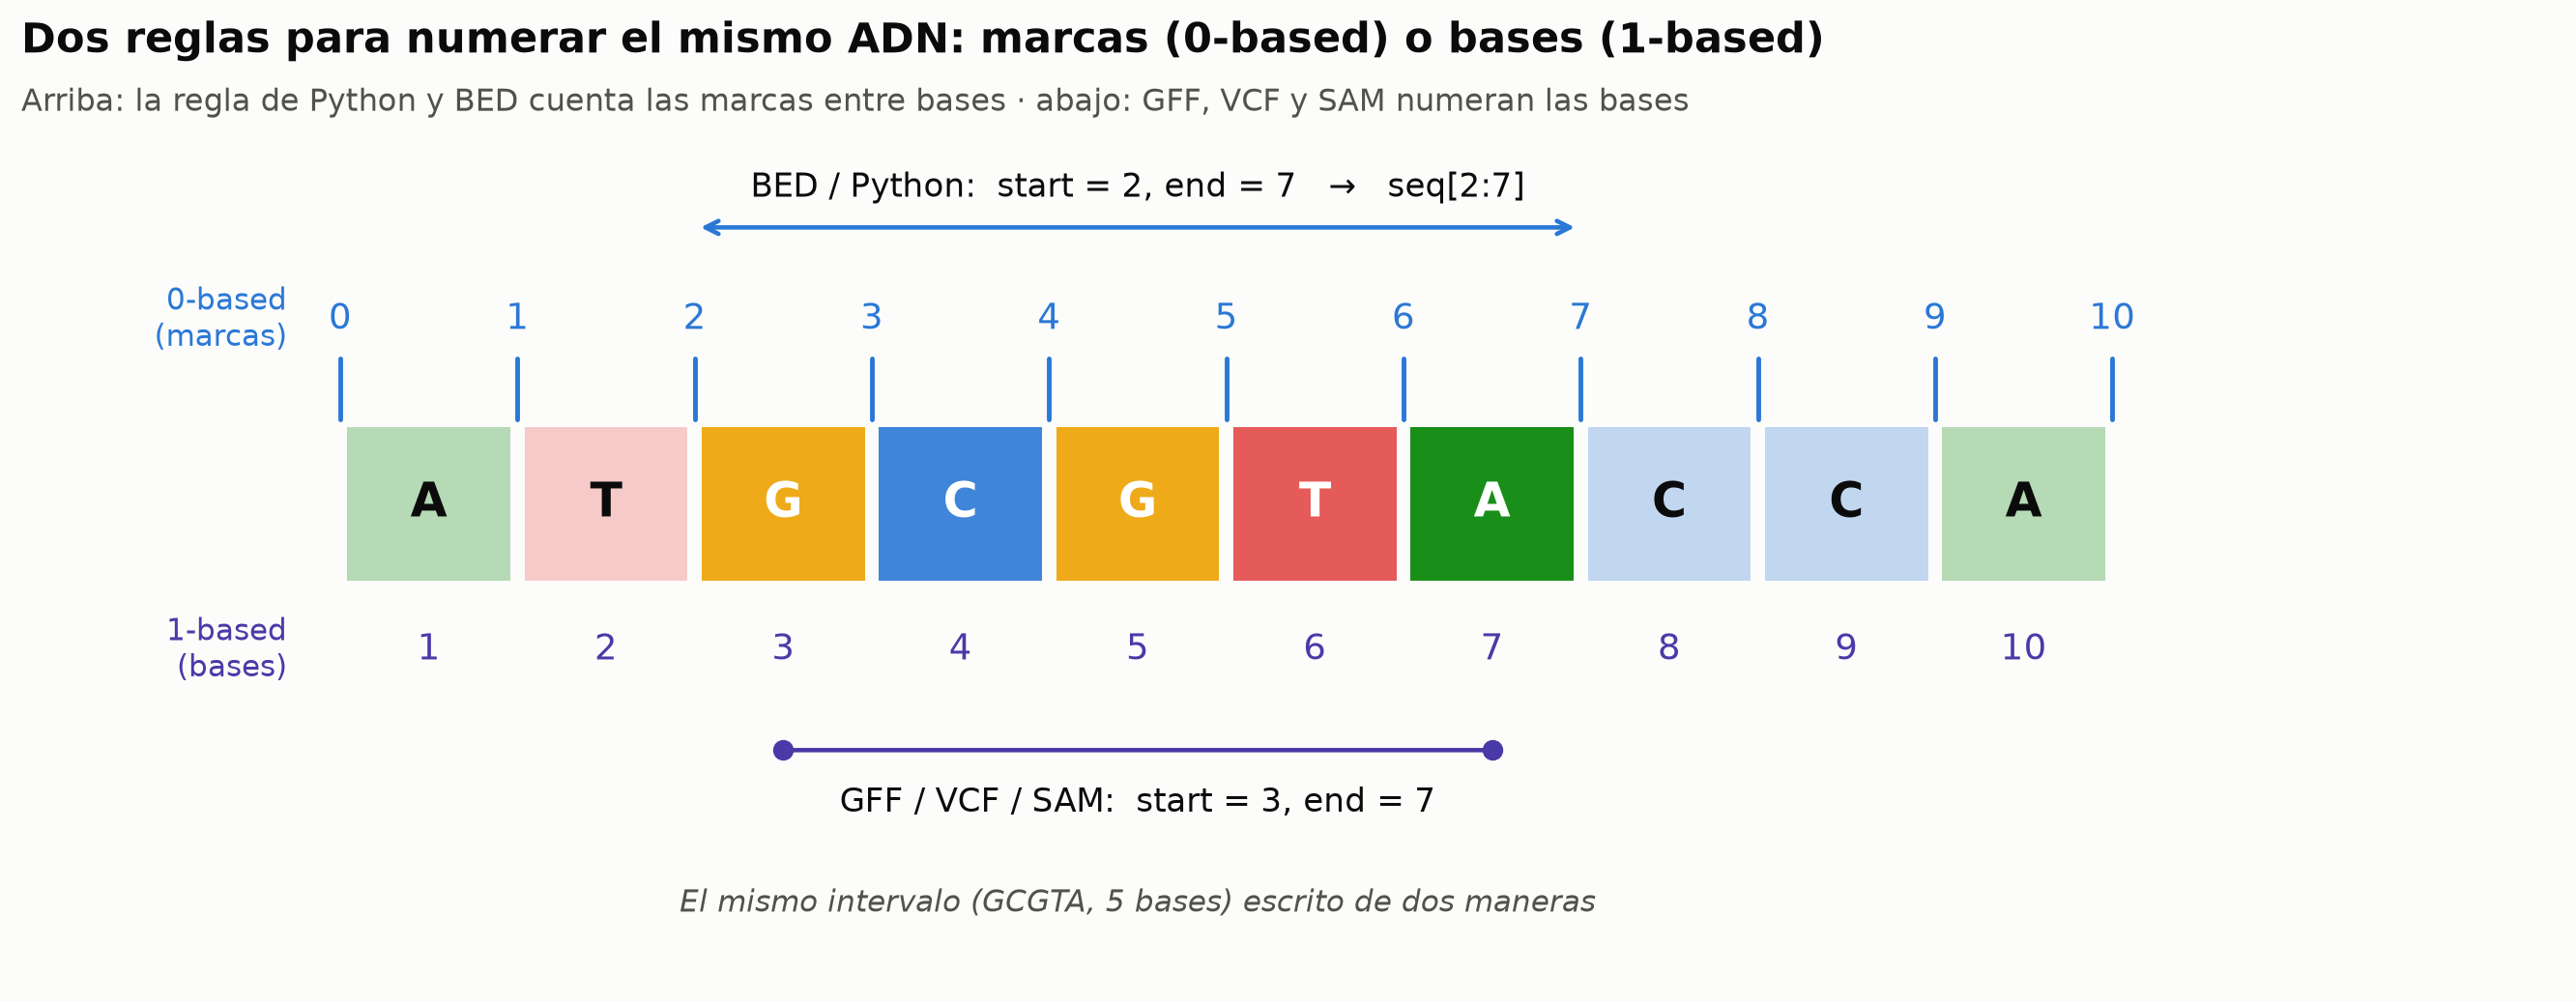

In [15]:
seq_demo = "ATGCGTACCA"
feat1 = (3, 7)                                    # 1-based cerrado: bases 3..7 = GCGTA
fig, ax = plt.subplots(figsize=(12, 4.6))
ax.set_xlim(-1.8, 12.5); ax.set_ylim(-2.6, 2.9); ax.axis("off")
for i, b in enumerate(seq_demo):
    inside = feat1[0] - 1 <= i < feat1[1]
    ax.add_patch(plt.Rectangle((i + 0.04, 0), 0.92, 1, color=ec.NUC_COLORS[b], alpha=0.9 if inside else 0.28, lw=0))
    ax.text(i + 0.5, 0.5, b, ha="center", va="center", fontsize=16, fontweight="bold",
            color="white" if inside else ec.INK)
    ax.text(i + 0.5, -0.45, str(i + 1), ha="center", va="center", fontsize=12, color=ec.VIOLET)   # 1-based
for m in range(len(seq_demo) + 1):
    ax.plot([m, m], [1.05, 1.45], color=ec.BLUE, lw=1.6)
    ax.text(m, 1.7, str(m), ha="center", va="center", fontsize=12, color=ec.BLUE)                  # 0-based
ax.text(-0.3, 1.7, "0-based\n(marcas)", ha="right", va="center", fontsize=10, color=ec.BLUE)
ax.text(-0.3, -0.45, "1-based\n(bases)", ha="right", va="center", fontsize=10, color=ec.VIOLET)
ax.annotate("", xy=(2, 2.3), xytext=(7, 2.3), arrowprops=dict(arrowstyle="<->", color=ec.BLUE, lw=1.5))
ax.text(4.5, 2.5, "BED / Python:  start = 2, end = 7   →   seq[2:7]", ha="center", fontsize=11, color=ec.INK)
ax.annotate("", xy=(2.5, -1.1), xytext=(6.5, -1.1), arrowprops=dict(arrowstyle="-", color=ec.VIOLET, lw=1.5))
ax.plot([2.5, 6.5], [-1.1, -1.1], "o", color=ec.VIOLET, markersize=6)
ax.text(4.5, -1.5, "GFF / VCF / SAM:  start = 3, end = 7", ha="center", fontsize=11, color=ec.INK)
ax.text(4.5, -2.15, "El mismo intervalo (GCGTA, 5 bases) escrito de dos maneras", ha="center", fontsize=10,
        color=ec.INK_2, style="italic")
ec.title(ax, "Dos reglas para numerar el mismo ADN: marcas (0-based) o bases (1-based)",
         "Arriba: la regla de Python y BED cuenta las marcas entre bases · abajo: GFF, VCF y SAM numeran las bases")
plt.show()

In [16]:
def one_to_zero(start1: int, end1: int) -> tuple:
    """[start1, end1] 1-based cerrado → [start0, end0) 0-based semiabierto."""
    return start1 - 1, end1

def zero_to_one(start0: int, end0: int) -> tuple:
    """[start0, end0) 0-based semiabierto → [start1, end1] 1-based cerrado."""
    return start0 + 1, end0

assert one_to_zero(3, 7) == (2, 7) and zero_to_one(2, 7) == (3, 7)
assert seq_demo[slice(*one_to_zero(3, 7))] == "GCGTA"

spike = next(f for f in sars.features if f.type == "CDS" and f.qualifiers.get("gene") == ["S"])
s1, e1 = int(spike.location.start) + 1, int(spike.location.end)    # Biopython ya guarda 0-based
print(f"GenBank (1-based):  {s1}..{e1}")
print(f"BED/Python (0-based): {one_to_zero(s1, e1)}")
print("❌ ref[21563:21566] =", ref[21563:21566], " ← corrido una base: ¡no es el ATG!")
s0, e0 = one_to_zero(s1, e1)
print("✔ ref[21562:21565] =", ref[s0:s0 + 3])
print("✔ traducción correcta:", Seq(ref[s0:e0]).translate(to_stop=True)[:20], "…")

GenBank (1-based):  21563..25384
BED/Python (0-based): (21562, 25384)
❌ ref[21563:21566] = TGT  ← corrido una base: ¡no es el ATG!
✔ ref[21562:21565] = ATG
✔ traducción correcta: MFVFLVLLPLVSSQCVNLTT …


✅ **Compruebe su comprensión.** Un VCF reporta un SNP en `POS = 100`. ¿Qué índice de Python usa para leer esa base
en la referencia? ¿Y qué línea BED de una sola base lo representa? *(Respuesta: `ref[99]`; `chrom  99  100`.)*

## 6. GenBank → GFF3 y BED: las anotaciones

El GenBank es riquísimo pero difícil de procesar (su estructura depende de la sangría del texto). Por eso las
anotaciones suelen distribuirse en **GFF3**: una tabla de **9 columnas** separadas por tabuladores, una fila por
elemento. Es como pasar de una ficha clínica escrita a mano a una hoja de cálculo.

| # | Columna | Ejemplo | Significado |
|---|---|---|---|
| 1 | seqid | `NC_045512.2` | secuencia (cromosoma) |
| 2 | source | `RefSeq` | quién hizo la anotación |
| 3 | type | `CDS` | tipo (término de la *Sequence Ontology*) |
| 4 | start | `21563` | inicio, **1-based** |
| 5 | end | `25384` | fin, **incluido** |
| 6 | score | `.` | puntaje (punto = vacío) |
| 7 | strand | `+` | hebra |
| 8 | phase | `0` | para CDS: bases a saltar hasta el primer codón completo |
| 9 | attributes | `ID=cds-S;Name=S` | pares `clave=valor` separados por `;` |

El **BED** es aún más austero: al menos 3 columnas (`chrom`, `start`, `end`) en coordenadas **0-based**, y
opcionalmente nombre, puntaje y hebra (BED6). Es el formato preferido para decir "estas son las regiones que me
interesan" (exones de un panel de genes, picos de ChIP-seq…).

Convirtamos las anotaciones de SARS-CoV-2. Un detalle fino: el CDS de ORF1ab tiene **dos partes** (el *frameshift*
ribosomal de la Lección 0.2), y en GFF3 cada parte es una fila con el **mismo ID** y su propia **fase**.

In [17]:
SO_TYPE = {"gene": "gene", "CDS": "CDS", "5'UTR": "five_prime_UTR", "3'UTR": "three_prime_UTR"}

def genbank_to_gff3(record):
    rows = []
    for k, feat in enumerate(record.features):
        if feat.type not in SO_TYPE:
            continue
        q = feat.qualifiers
        name = q.get("gene", [SO_TYPE[feat.type]])[0]
        fid = f"{feat.type.lower().replace(chr(39), '')}-{name}-{k}"
        attrs = f"ID={fid};Name={name}"
        if "product" in q:
            attrs += f";product={q['product'][0].replace(';', ',')}"
        done = 0                                             # bases de CDS ya recorridas (para la fase)
        for part in feat.location.parts:
            phase = (3 - done % 3) % 3 if feat.type == "CDS" else "."
            strand = "+" if part.strand == 1 else "-"
            rows.append([record.id, "RefSeq", SO_TYPE[feat.type], int(part.start) + 1, int(part.end),
                         ".", strand, phase, attrs])
            done += len(part)
    return pd.DataFrame(rows, columns=["seqid", "source", "type", "start", "end", "score", "strand", "phase",
                                       "attributes"])

gff = genbank_to_gff3(sars)
with open("sars.gff3", "w") as fh:
    fh.write("##gff-version 3\n")
    fh.write(f"##sequence-region {CHROM} 1 {len(ref)}\n")
    gff.to_csv(fh, sep="\t", header=False, index=False)
print("".join(open("sars.gff3").readlines()[:6]))
gff["type"].value_counts().to_frame("filas")

##gff-version 3
##sequence-region NC_045512.2 1 29903
NC_045512.2	RefSeq	five_prime_UTR	1	265	.	+	.	ID=5utr-five_prime_UTR-1;Name=five_prime_UTR
NC_045512.2	RefSeq	gene	266	21555	.	+	.	ID=gene-ORF1ab-2;Name=ORF1ab
NC_045512.2	RefSeq	CDS	266	13468	.	+	0	ID=cds-ORF1ab-3;Name=ORF1ab;product=ORF1ab polyprotein
NC_045512.2	RefSeq	CDS	13468	21555	.	+	0	ID=cds-ORF1ab-3;Name=ORF1ab;product=ORF1ab polyprotein



,filas
type,
CDS,13
gene,11
five_prime_UTR,1
three_prime_UTR,1


In [18]:
genes = gff[gff["type"] == "gene"].copy()
genes["name"] = genes["attributes"].str.extract(r"Name=([^;]+)")
bed = pd.DataFrame({"chrom": genes["seqid"], "start": genes["start"] - 1, "end": genes["end"],
                    "name": genes["name"], "score": 0, "strand": genes["strand"]})
bed.to_csv("sars_genes.bed", sep="\t", header=False, index=False)
print("".join(open("sars_genes.bed").readlines()[:4]))
print("Longitudes idénticas en ambos sistemas:",
      ((genes["end"] - genes["start"] + 1).values == (bed["end"] - bed["start"]).values).all())

NC_045512.2	265	21555	ORF1ab	0	+
NC_045512.2	21562	25384	S	0	+
NC_045512.2	25392	26220	ORF3a	0	+
NC_045512.2	26244	26472	E	0	+

Longitudes idénticas en ambos sistemas: True


### 🔍 Explorador interactivo de anotaciones

Cada barra es una fila del GFF3. Pase el cursor para ver, lado a lado, la línea **GFF** (1-based), la línea **BED**
equivalente (0-based) y el *slice* de Python que extrae exactamente esa secuencia. Note la fila doble de ORF1ab y las
UTRs en los extremos del genoma.

Resorting to unclean kill browser.


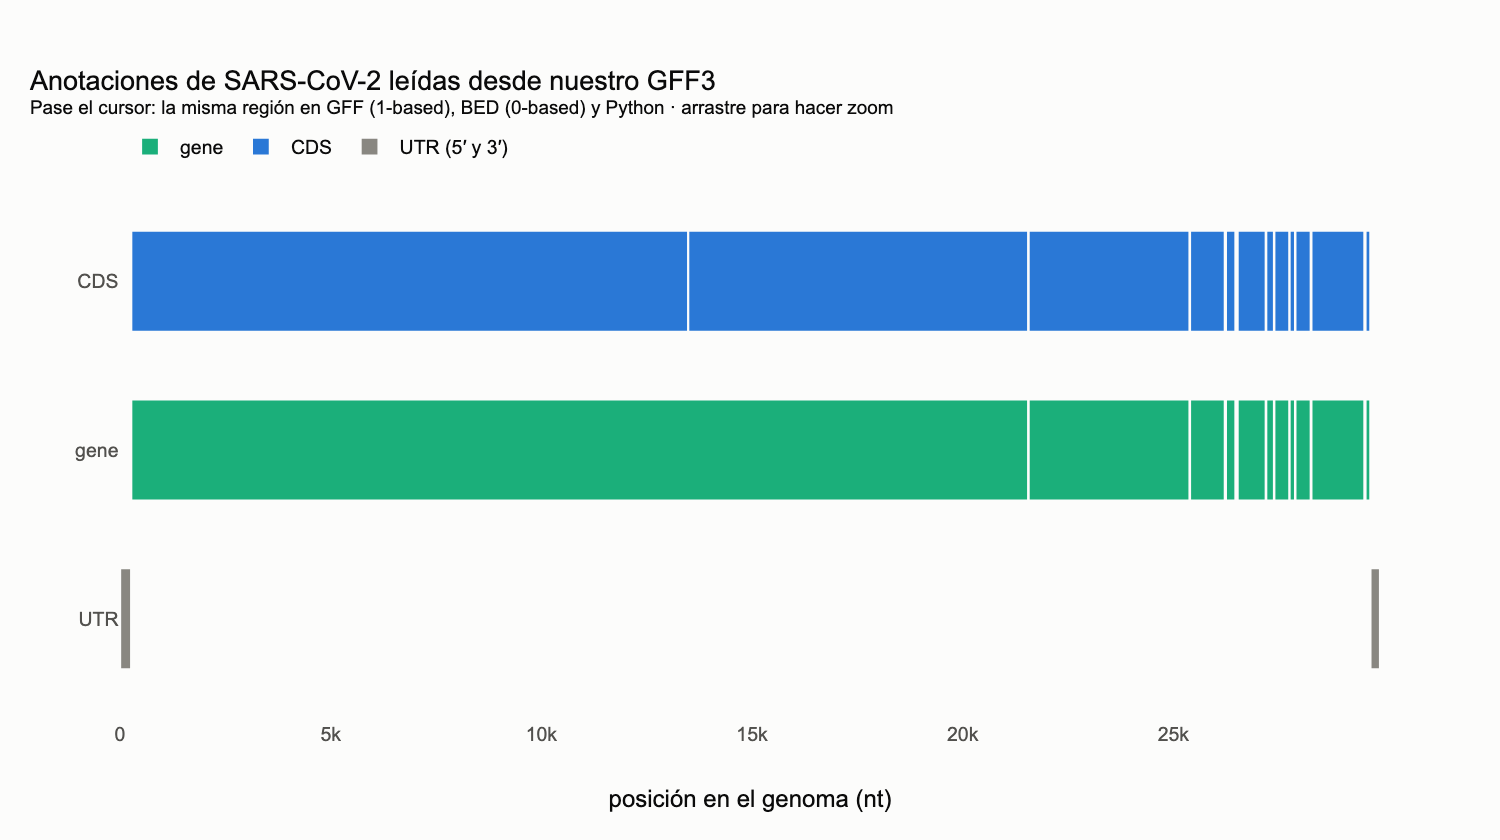

In [19]:
lane = {"five_prime_UTR": 0, "gene": 1, "CDS": 2, "three_prime_UTR": 0}
color = {"five_prime_UTR": ec.MUTED, "three_prime_UTR": ec.MUTED, "gene": ec.AQUA, "CDS": ec.BLUE}
legend_name = {"gene": "gene", "CDS": "CDS", "five_prime_UTR": "UTR (5′ y 3′)", "three_prime_UTR": "UTR (5′ y 3′)"}
fig = go.Figure()
for t in ["gene", "CDS", "five_prime_UTR", "three_prime_UTR"]:
    sub = gff[gff["type"] == t]
    hover = [f"<b>{r.type}</b> {r.attributes.split('Name=')[1].split(';')[0]}<br>"
             f"GFF (1-based): start={r.start}, end={r.end}, fase={r.phase}<br>"
             f"BED (0-based): start={r.start - 1}, end={r.end}<br>"
             f"Python: ref[{r.start - 1}:{r.end}] → {ref[r.start - 1:r.start + 5]}…<br>"
             f"longitud = {r.end - r.start + 1:,} nt" for r in sub.itertuples()]
    fig.add_trace(go.Bar(x=sub["end"] - sub["start"] + 1, base=sub["start"], y=[lane[t]] * len(sub),
                         orientation="h", marker=dict(color=color[t], line=dict(color=ec.SURFACE, width=1.5)),
                         name=legend_name[t], showlegend=(t != "three_prime_UTR"),
                         hovertext=hover, hoverinfo="text", width=0.6))
fig.update_layout(
    title=dict(text="Anotaciones de SARS-CoV-2 leídas desde nuestro GFF3"
                    "<br><sup>Pase el cursor: la misma región en GFF (1-based), BED (0-based) y Python · arrastre para hacer zoom</sup>"),
    barmode="overlay", height=380, margin=dict(t=120, l=80),
    yaxis=dict(tickvals=[0, 1, 2], ticktext=["UTR", "gene", "CDS"], showgrid=False, range=[-0.6, 2.6]),
    xaxis=dict(title="posición en el genoma (nt)", range=[0, len(ref)]),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0))
fig.show()

## 7. SAM: dónde cayó cada lectura

Después de secuenciar, un **alineador** (BWA, minimap2… Módulo 7) busca en qué lugar del genoma de referencia encaja
cada lectura. El resultado se escribe en **SAM** (*Sequence Alignment/Map*, Li *et al.*, 2009): un encabezado con
líneas `@` y luego **una fila por alineamiento** con 11 columnas obligatorias.

| # | Campo | Ejemplo | Significado |
|---|---|---|---|
| 1 | QNAME | `read_7` | nombre de la lectura |
| 2 | FLAG | `16` | banderas codificadas en bits (ver abajo) |
| 3 | RNAME | `NC_045512.2` | cromosoma donde cayó |
| 4 | POS | `21571` | posición **1-based** de la primera base alineada |
| 5 | MAPQ | `60` | confianza en la posición, en escala Phred |
| 6 | CIGAR | `20M2I28M` | cómo encaja la lectura (coincidencias, inserciones, deleciones…) |
| 7–9 | RNEXT, PNEXT, TLEN | `*  0  0` | datos de la pareja (lecturas pareadas) |
| 10 | SEQ | `ATGTTTG…` | secuencia (en la orientación de la referencia) |
| 11 | QUAL | `IIIHG?…` | calidades Phred+33 |

### La CIGAR: instrucciones para colocar la lectura

La CIGAR es como las **instrucciones de un GPS**: "avance 20, gire (hay 2 letras extra en la lectura), avance 28".
Cada operación es un número seguido de una letra:

| Op | Nombre | ¿Consume lectura? | ¿Consume referencia? | Ejemplo |
|---|---|---|---|---|
| `M` | *match/mismatch* alineado | sí | sí | base frente a base (igual o distinta) |
| `I` | inserción | sí | no | letras que la lectura tiene y la referencia no |
| `D` | deleción | no | sí | letras de la referencia que faltan en la lectura |
| `N` | salto (*intrón*) | no | sí | RNA-seq: la lectura salta un intrón |
| `S` | recorte suave (*soft clip*) | sí | no | extremo no alineado pero guardado en SEQ |
| `H` | recorte duro | no | no | extremo no alineado y **no** guardado |
| `=` / `X` | igual / distinto | sí | sí | versión explícita de `M` |

De la tabla salen dos fórmulas útiles:

$$
\text{longitud de la lectura} = \sum_{\text{op} \,\in\, \{M,I,S,=,X\}} n_{\text{op}}
\qquad\qquad
\text{tramo en la referencia} = \sum_{\text{op} \,\in\, \{M,D,N,=,X\}} n_{\text{op}}
$$

**Ejemplo a mano.** `5S15M2I10M3D18M`: la lectura mide $5 + 15 + 2 + 10 + 18 = 50$ bases, pero cubre
$15 + 10 + 3 + 18 = 46$ bases de la referencia, empezando en POS (el recorte suave **no** cuenta para POS).

In [20]:
CIGAR_RE = re.compile(r"(\d+)([MIDNSHP=X])")
CONSUMES = {"M": (1, 1), "I": (1, 0), "D": (0, 1), "N": (0, 1), "S": (1, 0),
            "H": (0, 0), "P": (0, 0), "=": (1, 1), "X": (1, 1)}      # (lectura, referencia)

def parse_cigar(cigar: str) -> list:
    return [(int(n), op) for n, op in CIGAR_RE.findall(cigar)]

def query_length(cigar):  return sum(n for n, op in parse_cigar(cigar) if CONSUMES[op][0])
def ref_span(cigar):      return sum(n for n, op in parse_cigar(cigar) if CONSUMES[op][1])

c = "5S15M2I10M3D18M"
print(parse_cigar(c))
print("longitud de la lectura =", query_length(c), "· tramo en la referencia =", ref_span(c))

[(5, 'S'), (15, 'M'), (2, 'I'), (10, 'M'), (3, 'D'), (18, 'M')]
longitud de la lectura = 50 · tramo en la referencia = 46


### 🧪 Construir lecturas con distintas CIGAR

Fabricamos seis lecturas de 50 nt a partir del inicio del gen S, cada una con una "historia" distinta: perfecta,
con un error de secuenciación, con una inserción, con una deleción, con un adaptador recortado y otra en la hebra
reversa. Luego escribimos un SAM real y dibujamos cada alineamiento a partir de su CIGAR.

In [21]:
def make_read(ref, pos1, cigar, rng, mismatch_at=()):
    """Fabrica la secuencia de una lectura que se alinea en pos1 con la CIGAR dada."""
    seq, r = [], pos1 - 1
    for n, op in parse_cigar(cigar):
        if op == "M":
            seq += list(ref[r:r + n]); r += n
        elif op == "D":
            r += n
        elif op in "IS":
            seq += list(rng.choice(list("ACGT"), n))
    for k in mismatch_at:                                   # errores de secuenciación puntuales
        seq[k] = "A" if seq[k] != "A" else "C"
    return "".join(seq)

rng = np.random.default_rng(7)
S0 = s1                                                     # inicio del gen S (1-based)
specs = [("read_perfecta", 0,  S0 + 0,  "50M",        ()),
         ("read_error",    0,  S0 + 6,  "50M",        (17,)),
         ("read_insercion",0,  S0 + 14, "20M2I28M",   ()),
         ("read_delecion", 0,  S0 + 22, "25M3D25M",   ()),
         ("read_adaptador",0,  S0 + 31, "5S45M",      ()),
         ("read_reversa",  16, S0 + 40, "50M",        ())]
sam_rows = []
for name, flag, pos, cigar, mm in specs:
    seq = make_read(ref, pos, cigar, rng, mm)
    qual = "".join(phred_to_char(v) for v in simulate_quality(1, len(seq), rng)[0])
    sam_rows.append([name, flag, CHROM, pos, 60, cigar, "*", 0, 0, seq, qual])

with open("demo.sam", "w") as fh:
    fh.write(f"@HD\tVN:1.6\tSO:coordinate\n@SQ\tSN:{CHROM}\tLN:{len(ref)}\n@PG\tID:curso\tPN:make_read\n")
    for row in sam_rows:
        fh.write("\t".join(map(str, row)) + "\n")
print(open("demo.sam").read()[:600])

@HD	VN:1.6	SO:coordinate
@SQ	SN:NC_045512.2	LN:29903
@PG	ID:curso	PN:make_read
read_perfecta	0	NC_045512.2	21563	60	50M	*	0	0	ATGTTTGTTTTTCTTGTTTTATTGCCACTAGTCTCTAGTCAGTGTGTTAA	GEDEDFIEDGFFCEFBDABADADDC>BBB?A??C?@B>??>;>@:><:?<
read_error	0	NC_045512.2	21569	60	50M	*	0	0	GTTTTTCTTGTTTTATTACCACTAGTCTCTAGTCAGTGTGTTAATCTTAC	GFHFGIEFEFCDEGHBCFADDGECCCFBBCBA?A@CA@A>A>?;>98;9;
read_insercion	0	NC_045512.2	21577	60	20M2I28M	*	0	0	TGTTTTATTGCCACTAGTCTGCCTAGTCAGTGTGTTAATCTTACAACCAG	EEDDFEBDDBDBFDDBC?AC>D?C@CA>CC@??=A=><<;?<><::9:98
read_delecion	0	NC_045512.2	21585	60	25M3D25M	*	0	0	TGCCACTAGTCTCTAGTCA


In [22]:
def render_alignment(ref, pos1, seq, cigar):
    """Devuelve tres líneas de texto: referencia, marcas de coincidencia y lectura."""
    r, q = pos1 - 1, 0
    top, mid, bot = [], [], []
    for n, op in parse_cigar(cigar):
        for _ in range(n):
            if op in "M=X":
                a, b = ref[r], seq[q]
                top.append(a); bot.append(b); mid.append("|" if a == b else "·"); r += 1; q += 1
            elif op == "I":
                top.append("-"); bot.append(seq[q]); mid.append(" "); q += 1
            elif op == "D":
                top.append(ref[r]); bot.append("-"); mid.append(" "); r += 1
            elif op == "S":
                top.append(" "); bot.append(seq[q].lower()); mid.append(" "); q += 1
    return "".join(top), "".join(mid), "".join(bot)

for name, flag, chrom, pos, mapq, cigar, *_rest in sam_rows:
    seq = _rest[3]
    t, m, b = render_alignment(ref, pos, seq, cigar)
    print(f"{name}  POS={pos}  CIGAR={cigar}")
    print("  ref :", t); print("        ", m); print("  read:", b, "\n")

read_perfecta  POS=21563  CIGAR=50M
  ref : ATGTTTGTTTTTCTTGTTTTATTGCCACTAGTCTCTAGTCAGTGTGTTAA
         ||||||||||||||||||||||||||||||||||||||||||||||||||
  read: ATGTTTGTTTTTCTTGTTTTATTGCCACTAGTCTCTAGTCAGTGTGTTAA 

read_error  POS=21569  CIGAR=50M
  ref : GTTTTTCTTGTTTTATTGCCACTAGTCTCTAGTCAGTGTGTTAATCTTAC
         |||||||||||||||||·||||||||||||||||||||||||||||||||
  read: GTTTTTCTTGTTTTATTACCACTAGTCTCTAGTCAGTGTGTTAATCTTAC 

read_insercion  POS=21577  CIGAR=20M2I28M
  ref : TGTTTTATTGCCACTAGTCT--CTAGTCAGTGTGTTAATCTTACAACCAG
         ||||||||||||||||||||  ||||||||||||||||||||||||||||
  read: TGTTTTATTGCCACTAGTCTGCCTAGTCAGTGTGTTAATCTTACAACCAG 

read_delecion  POS=21585  CIGAR=25M3D25M
  ref : TGCCACTAGTCTCTAGTCAGTGTGTTAATCTTACAACCAGAACTCAATTACCC
         |||||||||||||||||||||||||   |||||||||||||||||||||||||
  read: TGCCACTAGTCTCTAGTCAGTGTGT---TCTTACAACCAGAACTCAATTACCC 

read_adaptador  POS=21594  CIGAR=5S45M
  ref :      TCTCTAGTCAGTGTGTTAATCTTACAACCAGAACTCAATTACCCC
              |||||||

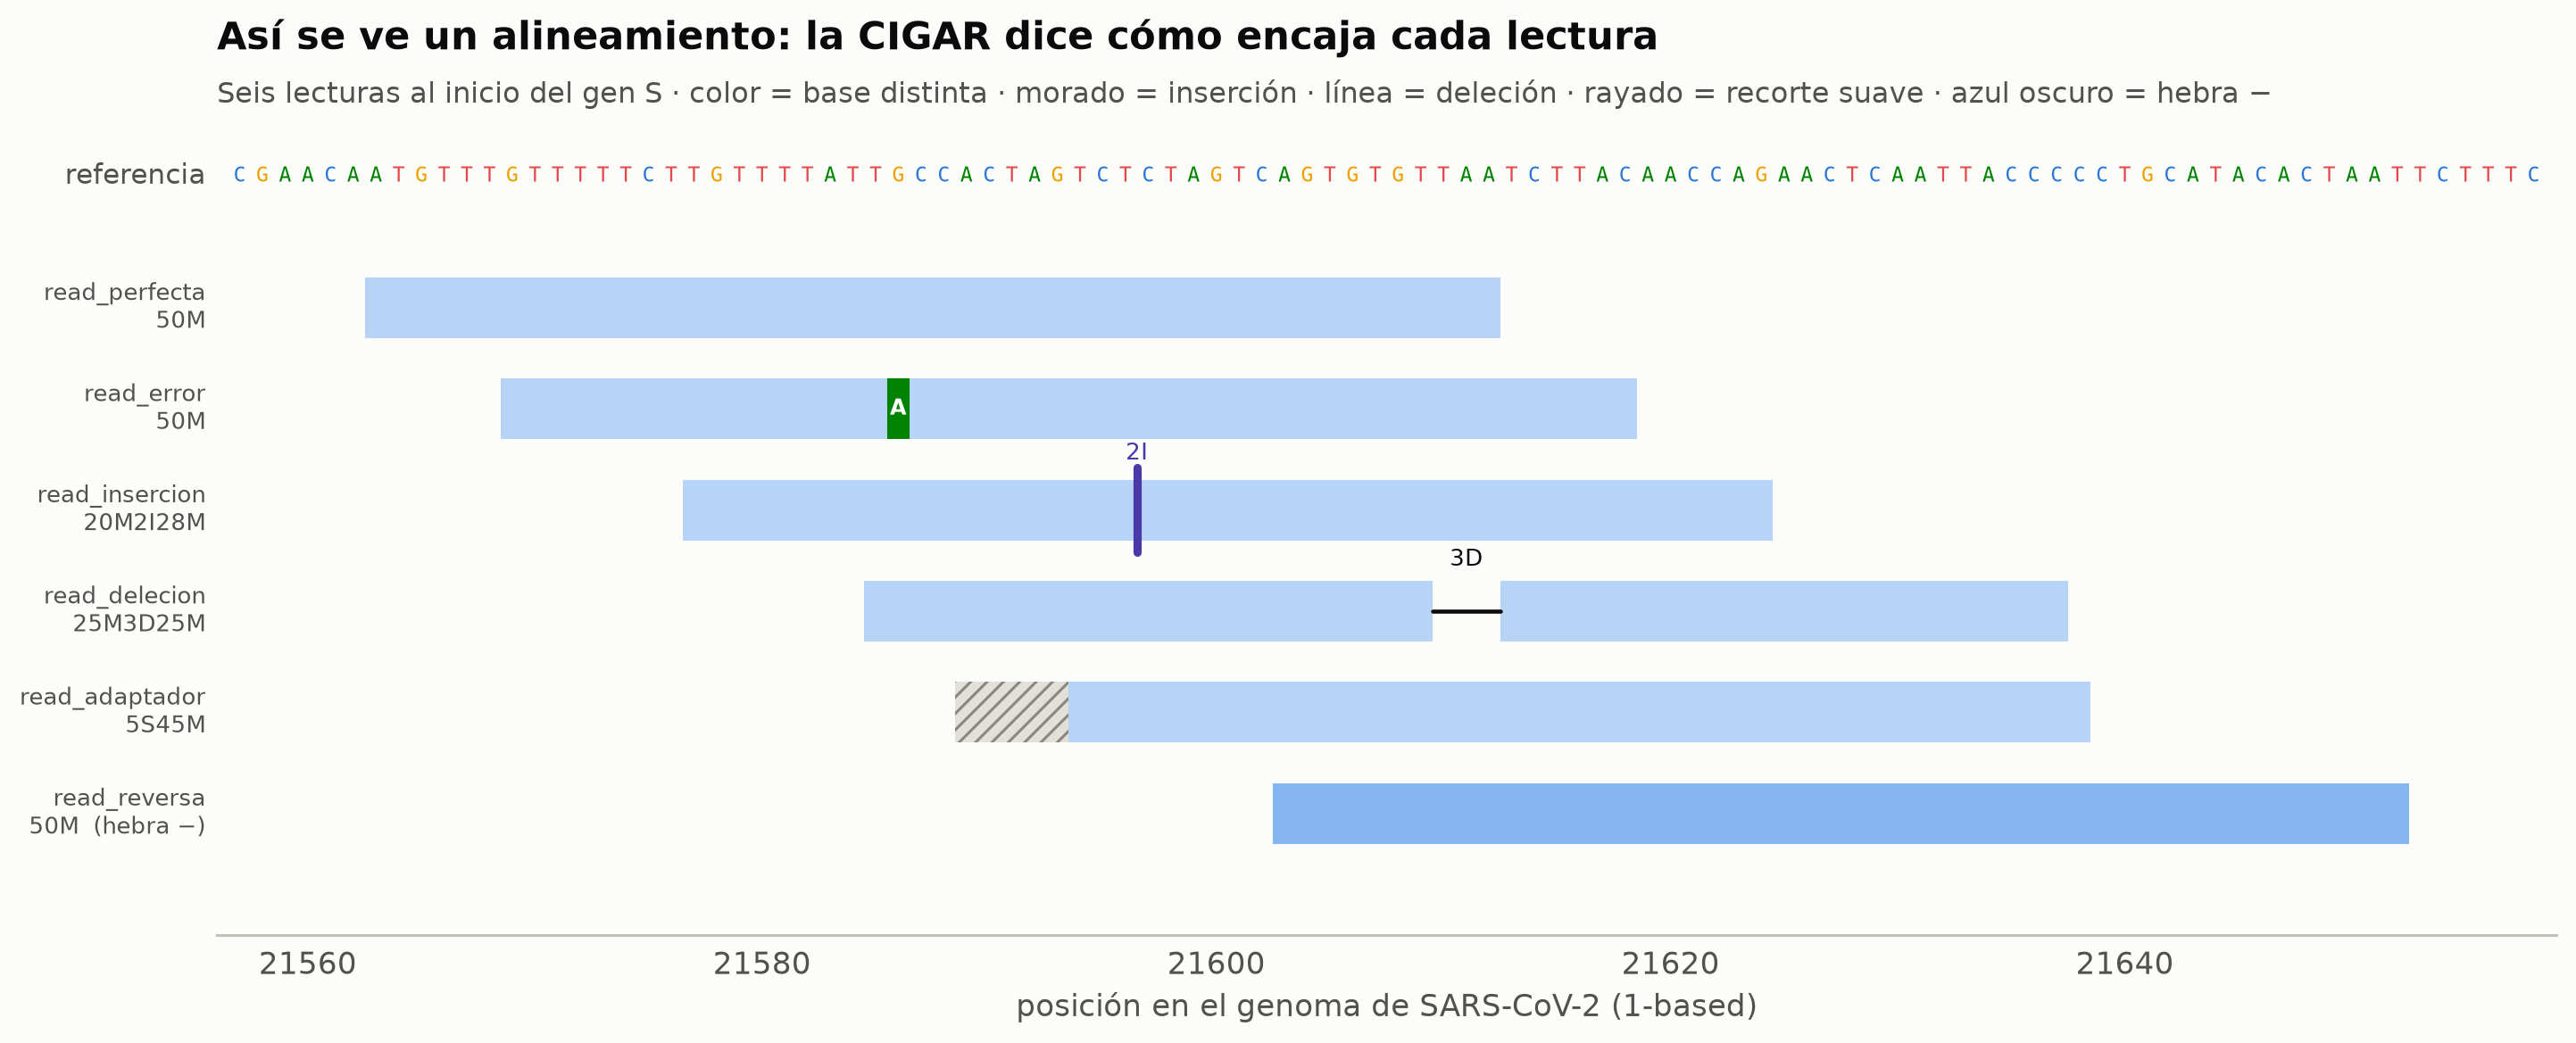

In [23]:
win0, win1 = S0 - 6, S0 + 96                                 # ventana de la referencia a dibujar (1-based)
fig, ax = plt.subplots(figsize=(13, 5.2))
for x in range(win0, win1):
    b = ref[x - 1]
    ax.text(x, 7.1, b, ha="center", va="center", fontsize=7.5, family="DejaVu Sans Mono", color=ec.NUC_COLORS[b])
ax.text(win0 - 1.5, 7.1, "referencia", ha="right", va="center", fontsize=10, color=ec.INK_2)
for row, (name, flag, chrom, pos, mapq, cigar, _, _, _, seq, _q) in enumerate(sam_rows):
    y = 5.8 - row
    r, q = pos, 0
    for n, op in parse_cigar(cigar):
        if op == "S":
            ax.add_patch(plt.Rectangle((r - n - 0.5, y - 0.3), n, 0.6, facecolor=ec.GRID, hatch="////",
                                       edgecolor=ec.MUTED, lw=0))
            q += n
        elif op == "M":
            ax.add_patch(plt.Rectangle((r - 0.5, y - 0.3), n, 0.6, color=ec.SEQ_BLUE[1] if flag == 0 else ec.SEQ_BLUE[3], lw=0))
            for k in range(n):
                if seq[q + k] != ref[r + k - 1]:
                    ax.add_patch(plt.Rectangle((r + k - 0.5, y - 0.3), 1, 0.6, color=ec.NUC_COLORS[seq[q + k]], lw=0))
                    ax.text(r + k, y, seq[q + k], ha="center", va="center", fontsize=8, color="white", fontweight="bold")
            r += n; q += n
        elif op == "D":
            ax.plot([r - 0.5, r + n - 0.5], [y, y], color=ec.INK, lw=1.5)
            ax.text(r + n / 2 - 0.5, y + 0.45, f"{n}D", ha="center", fontsize=8.5, color=ec.INK)
            r += n
        elif op == "I":
            ax.plot([r - 0.5, r - 0.5], [y - 0.42, y + 0.42], color=ec.VIOLET, lw=3)
            ax.text(r - 0.5, y + 0.5, f"{n}I", ha="center", fontsize=8.5, color=ec.VIOLET)
            q += n
    ax.text(win0 - 1.5, y, f"{name}\n{cigar}" + ("  (hebra −)" if flag & 16 else ""), ha="right", va="center",
            fontsize=8.5, color=ec.INK_2)
ax.set_xlim(win0 - 1, win1); ax.set_ylim(-0.4, 7.6)
ax.set_yticks([]); ax.grid(False); ax.spines["left"].set_visible(False)
ax.set_xlabel("posición en el genoma de SARS-CoV-2 (1-based)")
ec.title(ax, "Así se ve un alineamiento: la CIGAR dice cómo encaja cada lectura",
         "Seis lecturas al inicio del gen S · color = base distinta · morado = inserción · línea = deleción · rayado = recorte suave · azul oscuro = hebra −")
plt.show()

🔎 **Qué observamos.** La lectura con un error de secuenciación muestra un único cuadro de color; la inserción es una
marca morada **entre** dos bases de la referencia (porque no ocupa lugar en ella); la deleción es un hueco que sí
ocupa referencia; y el adaptador recortado "cuelga" a la izquierda de POS. Esta es, en miniatura, la vista que
ofrecen visores como IGV.

### 🎬 Recorriendo una CIGAR paso a paso

La animación sigue la CIGAR `5S15M2I10M3D18M` columna por columna. Observe los dos contadores: la posición en la
lectura avanza con `S`, `M` e `I`; la posición en la referencia avanza con `M` y `D`.

![Vista previa: dos punteros avanzan por la lectura y la referencia según cada operación de la CIGAR](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-02-formatos-bases-datos/2.1_cigar.gif)

*Vista previa: dos punteros avanzan por la lectura y la referencia según cada operación de la CIGAR*

In [24]:
cig = "5S15M2I10M3D18M"
pos_demo = S0 + 60
read_demo = make_read(ref, pos_demo, cig, np.random.default_rng(3))
top, mid, bot = render_alignment(ref, pos_demo, read_demo, cig)
ops_expanded = [op for n, op in parse_cigar(cig) for _ in range(n)]
ncol = len(top)
op_color = {"S": ec.MUTED, "M": ec.BLUE, "I": ec.VIOLET, "D": ec.ORANGE}

fig, ax = plt.subplots(figsize=(13, 3.9))
ax.set_xlim(-6, ncol + 1); ax.set_ylim(-1.9, 3.2); ax.axis("off")
for j in range(ncol):
    ax.text(j, 1, top[j], ha="center", va="center", family="DejaVu Sans Mono", fontsize=10,
            color=ec.NUC_COLORS.get(top[j], ec.MUTED))
    ax.text(j, 0, bot[j], ha="center", va="center", family="DejaVu Sans Mono", fontsize=10,
            color=ec.NUC_COLORS.get(bot[j].upper(), ec.MUTED) if bot[j] != "-" else ec.MUTED)
ax.text(-1.5, 1, "referencia", ha="right", va="center", fontsize=10, color=ec.INK_2)
ax.text(-1.5, 0, "lectura", ha="right", va="center", fontsize=10, color=ec.INK_2)
pieces, x0 = [], 0
for n, op in parse_cigar(cig):                               # la CIGAR escrita arriba, una pieza por operación
    t = ax.text(x0 + n / 2 - 0.5, 2.5, f"{n}{op}", ha="center", va="center", fontsize=12, color=ec.MUTED)
    ax.plot([x0 - 0.45, x0 + n - 0.55], [2.1, 2.1], color=op_color[op], lw=3, solid_capstyle="butt")
    pieces.append((x0, x0 + n, t)); x0 += n
cursor = plt.Rectangle((-0.5, -0.45), 1, 1.9, facecolor=ec.YELLOW, alpha=0.3, lw=0)
ax.add_patch(cursor)
counter = ax.text(ncol / 2, -1.3, "", ha="center", va="center", fontsize=11, color=ec.INK)
ax.set_title(f"Recorriendo la CIGAR {cig} (POS = {pos_demo})", loc="left")

def update(f):
    cursor.set_x(f - 0.5)
    op = ops_expanded[f]
    q_done = sum(CONSUMES[o][0] for o in ops_expanded[:f + 1])
    r_done = sum(CONSUMES[o][1] for o in ops_expanded[:f + 1])
    for a, b, t in pieces:
        active = a <= f < b
        t.set_color(ec.INK if active else ec.MUTED); t.set_fontweight("bold" if active else "normal")
    counter.set_text(f"operación {op}  ·  bases de la lectura usadas: {q_done}  ·  bases de la referencia usadas: {r_done}"
                     f"  →  posición en la referencia: {pos_demo + r_done - 1 if r_done else '—'}")
    return [cursor, counter] + [t for *_, t in pieces]

ec.animate(fig, update, frames=ncol, interval=260, name="2.1_cigar")

### La FLAG: doce interruptores en un solo número

La columna FLAG guarda **12 respuestas sí/no** en un único entero, como una fila de interruptores de luz: cada
interruptor es un **bit**, y el número es la suma de las potencias de 2 de los interruptores encendidos.

| Bit | Decimal | Significado (si está encendido) |
|---|---|---|
| 0x1 | 1 | la lectura es parte de un par |
| 0x2 | 2 | el par se alineó "correctamente" (orientación y distancia esperadas) |
| 0x4 | 4 | esta lectura **no** se alineó |
| 0x8 | 8 | la pareja no se alineó |
| 0x10 | 16 | esta lectura está en la **hebra reversa** |
| 0x20 | 32 | la pareja está en la hebra reversa |
| 0x40 | 64 | es la **primera** lectura del par (R1) |
| 0x80 | 128 | es la **segunda** lectura del par (R2) |
| 0x100 | 256 | alineamiento **secundario** |
| 0x200 | 512 | no pasó los filtros de calidad |
| 0x400 | 1024 | **duplicado** de PCR u óptico |
| 0x800 | 2048 | alineamiento **suplementario** (quimérico) |

**Ejemplo a mano: FLAG = 99.** Descomponemos en potencias de 2: $99 = 64 + 32 + 2 + 1$. Es decir: forma parte de un
par (1), el par está bien alineado (2), su pareja está en la hebra reversa (32) y es la lectura R1 (64). Su pareja
típica tiene FLAG $147 = 128 + 16 + 2 + 1$.

En código, se pregunta por un bit con el operador **Y binario** `&`: `flag & 16` es distinto de cero si y sólo si el
bit de la hebra reversa está encendido.

In [25]:
FLAG_BITS = [(1, "pareada"), (2, "par correcto"), (4, "no alineada"), (8, "pareja no alineada"),
             (16, "hebra reversa"), (32, "pareja reversa"), (64, "R1"), (128, "R2"),
             (256, "secundaria"), (512, "falla QC"), (1024, "duplicado"), (2048, "suplementaria")]

def decode_flag(flag: int) -> list:
    return [name for bit, name in FLAG_BITS if flag & bit]

for f in [0, 4, 16, 99, 147, 83, 163, 1024 + 99]:
    print(f"{f:>5} = {' + '.join(str(b) for b, _ in FLAG_BITS if f & b) or '0':<22} → {decode_flag(f)}")

    0 = 0                      → []
    4 = 4                      → ['no alineada']
   16 = 16                     → ['hebra reversa']
   99 = 1 + 2 + 32 + 64        → ['pareada', 'par correcto', 'pareja reversa', 'R1']
  147 = 1 + 2 + 16 + 128       → ['pareada', 'par correcto', 'hebra reversa', 'R2']
   83 = 1 + 2 + 16 + 64        → ['pareada', 'par correcto', 'hebra reversa', 'R1']
  163 = 1 + 2 + 32 + 128       → ['pareada', 'par correcto', 'pareja reversa', 'R2']
 1123 = 1 + 2 + 32 + 64 + 1024 → ['pareada', 'par correcto', 'pareja reversa', 'R1', 'duplicado']


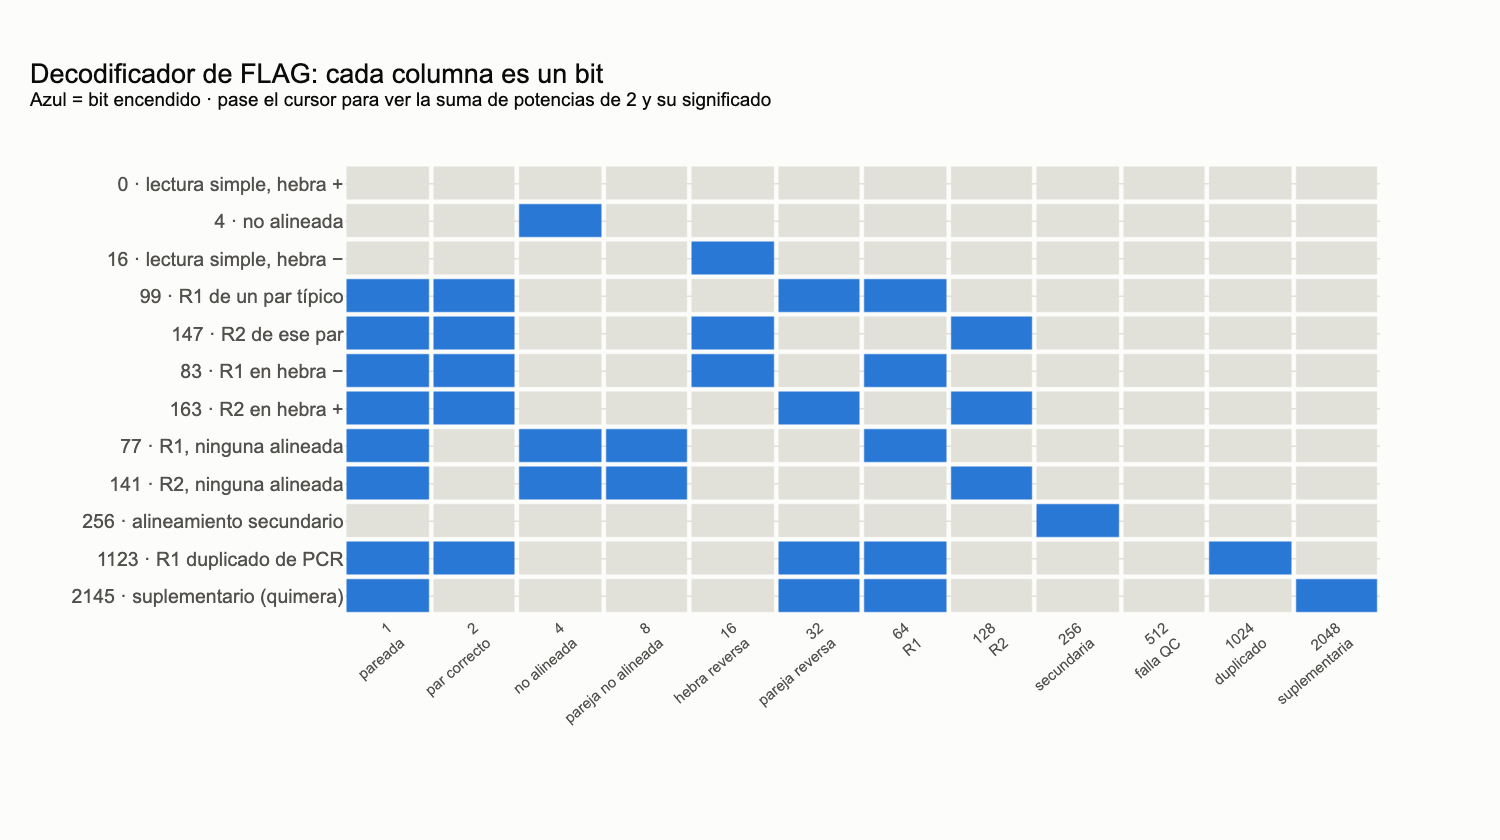

In [26]:
examples = {0: "lectura simple, hebra +", 4: "no alineada", 16: "lectura simple, hebra −",
            99: "R1 de un par típico", 147: "R2 de ese par", 83: "R1 en hebra −", 163: "R2 en hebra +",
            77: "R1, ninguna alineada", 141: "R2, ninguna alineada", 256: "alineamiento secundario",
            1123: "R1 duplicado de PCR", 2145: "suplementario (quimera)"}
flags = list(examples)
Z = np.array([[1 if f & b else 0 for b, _ in FLAG_BITS] for f in flags])
hover = [[f"FLAG {f} ({examples[f]})<br>bit {b} = <b>{name}</b>: {'sí ✔' if f & b else 'no'}"
          f"<br>{f} = {' + '.join(str(bb) for bb, _ in FLAG_BITS if f & bb) or '0'}"
          for b, name in FLAG_BITS] for f in flags]
fig = go.Figure(go.Heatmap(z=Z, x=[f"{b}<br>{name}" for b, name in FLAG_BITS],
                           y=[f"{f} · {examples[f]}" for f in flags],
                           colorscale=[[0, ec.GRID], [1, ec.BLUE]], showscale=False, xgap=3, ygap=3,
                           text=hover, hoverinfo="text"))
fig.update_layout(
    title=dict(text="Decodificador de FLAG: cada columna es un bit"
                    "<br><sup>Azul = bit encendido · pase el cursor para ver la suma de potencias de 2 y su significado</sup>"),
    height=600, margin=dict(t=110, l=230, b=150), yaxis=dict(autorange="reversed"),
    xaxis=dict(side="bottom", tickangle=-40, tickfont=dict(size=10)))
fig.show()

✅ **Compruebe su comprensión.** ¿Qué FLAG tiene una lectura R2, pareada, con el par bien alineado, en la hebra
reversa y marcada como duplicado? *(Respuesta: $1 + 2 + 16 + 128 + 1024 = 1171$.)*

## 8. BAM e índices: comprimir sin perder el acceso rápido

Un SAM de un genoma humano a 30× de cobertura pesa **cientos de gigabytes**. La versión binaria, **BAM**, resuelve
dos problemas a la vez:

1. **Tamaño.** BAM comprime los datos con **BGZF**: gzip, pero en **bloques independientes** de hasta 64 KB.
2. **Acceso aleatorio.** Si el archivo está **ordenado por coordenada**, un **índice** (`.bai`) anota en qué bloque
   empieza cada región del genoma. Pedir "las lecturas del gen S" ya no requiere leer todo el archivo: se salta
   directo al bloque correcto.

Es la diferencia entre un libro con **índice alfabético** al final y uno sin índice: el contenido es el mismo, pero
en el primero usted encuentra "replicación" en segundos. ¿Y por qué bloques independientes? Porque un gzip normal es
como una novela: para leer el capítulo 30 hay que "descomprimir" los 29 anteriores. Con bloques, cada capítulo se
puede abrir por separado.

🤔 **Antes de ejecutar, prediga.** Un SAM de texto comprimido con gzip y un BAM, ¿cuál cree que pesará menos?
¿Mucho menos o parecido?

In [27]:
# Un SAM "grande": 40 000 lecturas de 150 nt (≈ 200× de cobertura del genoma viral)
rng = np.random.default_rng(99)
n_big = 40_000
big_starts = np.sort(rng.integers(0, len(ref) - READ_LEN, size=n_big))
big_q = simulate_quality(n_big, READ_LEN, rng)
with open("big.sam", "w") as fh:
    fh.write(f"@HD\tVN:1.6\tSO:coordinate\n@SQ\tSN:{CHROM}\tLN:{len(ref)}\n")
    for i, s in enumerate(big_starts):
        qual = (big_q[i] + 33).astype(np.uint8).tobytes().decode()
        fh.write(f"r{i}\t0\t{CHROM}\t{s + 1}\t60\t{READ_LEN}M\t*\t0\t0\t{ref[s:s + READ_LEN]}\t{qual}\n")
with open("big.sam", "rb") as fi, gzip.open("big.sam.gz", "wb") as fo:
    shutil.copyfileobj(fi, fo)
sizes = {"SAM (texto)": os.path.getsize("big.sam"), "SAM + gzip": os.path.getsize("big.sam.gz")}

try:
    import pysam
except ImportError:
    if IN_COLAB:
        %pip install -q pysam
    try:
        import pysam
    except ImportError:
        pysam = None

if pysam is not None:
    pysam.view("-b", "-o", "big.bam", "big.sam", catch_stdout=False)
    pysam.index("big.bam")
    sizes["BAM"] = os.path.getsize("big.bam")
    bai_kb = os.path.getsize("big.bam.bai") / 1e3
    print(f"El índice big.bam.bai pesa sólo {bai_kb:.1f} KB")
pd.Series({k: f"{v / 1e6:.2f} MB" for k, v in sizes.items()}, name="tamaño").to_frame()

El índice big.bam.bai pesa sólo 0.2 KB


,tamaño
SAM (texto),13.69 MB
SAM + gzip,3.71 MB
BAM,3.80 MB


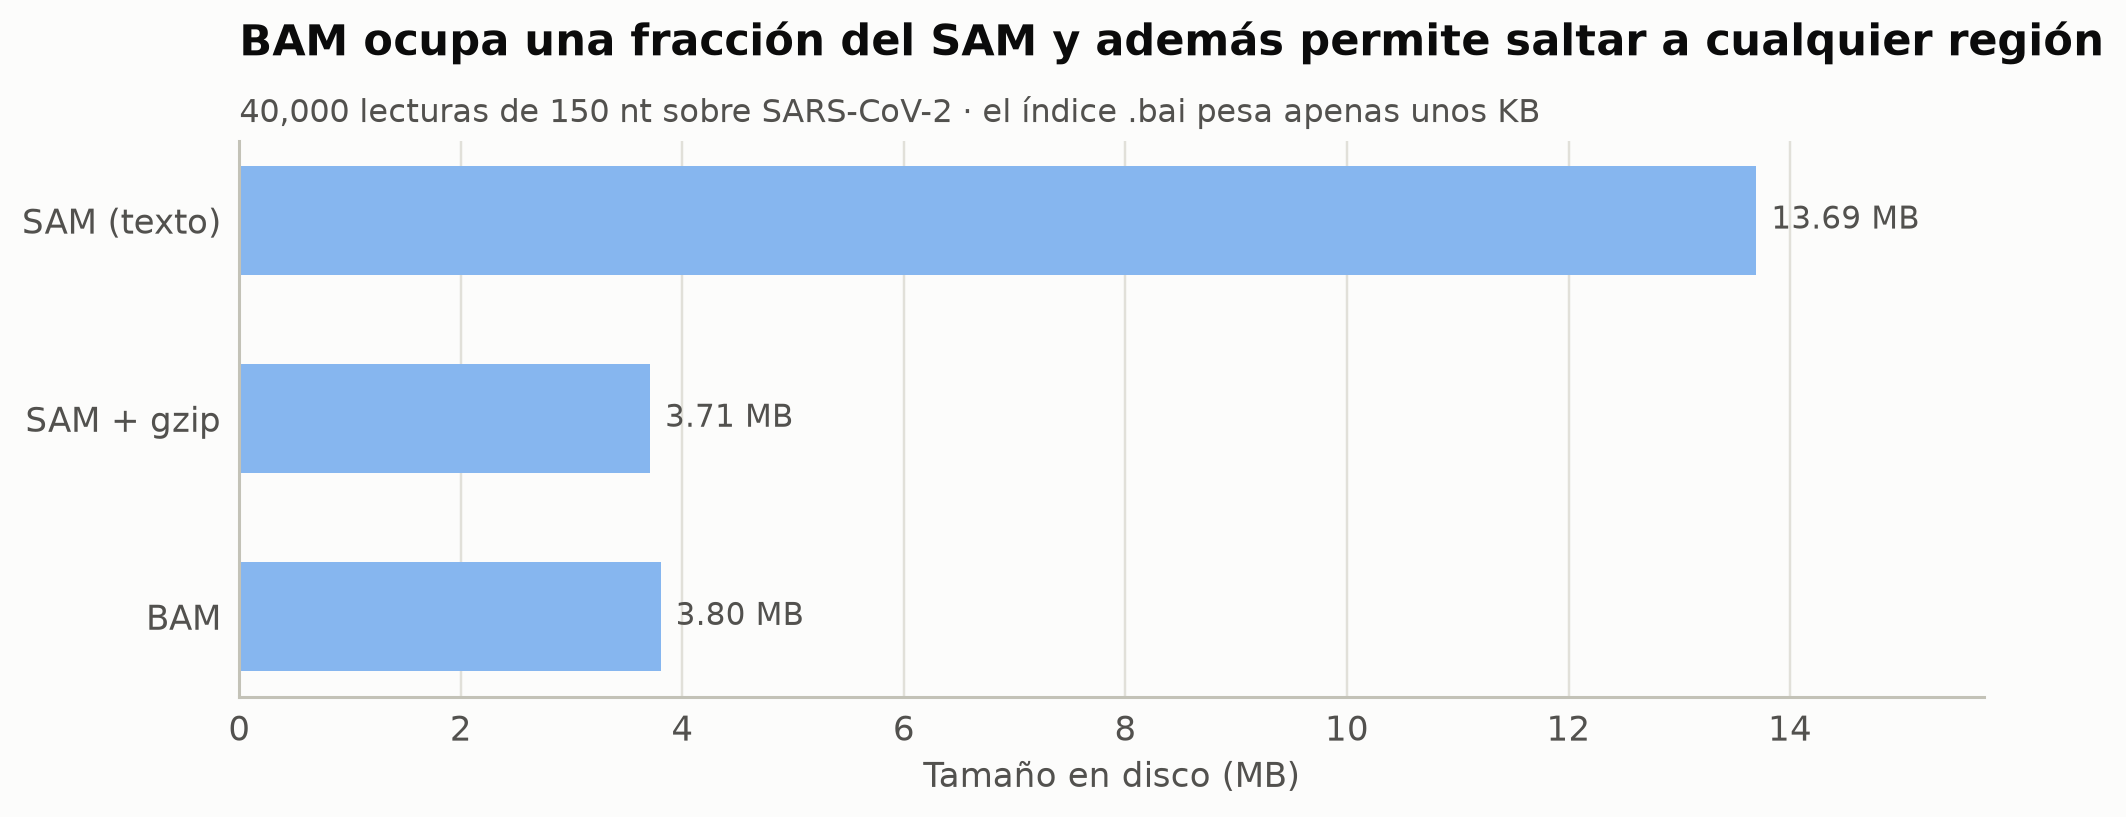

In [28]:
fig, ax = plt.subplots(figsize=(9, 3.6))
names, vals = list(sizes), [v / 1e6 for v in sizes.values()]
ax.barh(names[::-1], vals[::-1], color=[ec.SEQ_BLUE[3]] * len(vals), height=0.55)
for y, v in enumerate(vals[::-1]):
    ax.text(v + max(vals) * 0.01, y, f"{v:.2f} MB", va="center", fontsize=10, color=ec.INK_2)
ax.set_xlabel("Tamaño en disco (MB)"); ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.set_xlim(0, max(vals) * 1.15)
ec.title(ax, f"BAM ocupa una fracción del SAM y además permite saltar a cualquier región",
         f"{n_big:,} lecturas de {READ_LEN} nt sobre SARS-CoV-2 · el índice .bai pesa apenas unos KB")
plt.show()

In [29]:
if pysam is not None:
    region = (CHROM, s0, e0)                                     # gen S, coordenadas 0-based
    t0 = time.perf_counter()
    with pysam.AlignmentFile("big.bam") as bam:
        n_idx = bam.count(*region)                               # usa el índice: salta al bloque correcto
    t_idx = time.perf_counter() - t0
    t0 = time.perf_counter()
    with pysam.AlignmentFile("big.bam") as bam:
        n_scan = sum(1 for a in bam.fetch(until_eof=True)
                     if a.reference_end > s0 and a.reference_start < e0)    # lee TODO el archivo
    t_scan = time.perf_counter() - t0
    print(f"Lecturas que tocan el gen S: con índice = {n_idx:,} ({t_idx * 1e3:.1f} ms) · "
          f"leyendo todo = {n_scan:,} ({t_scan * 1e3:.1f} ms)")
    with pysam.AlignmentFile("big.bam") as bam:
        a = next(bam.fetch(CHROM, s0, s0 + 1))
        print("\nPrimer alineamiento que toca el inicio del gen S (pysam usa 0-based: reference_start):")
        print(f"  {a.query_name}  POS(SAM, 1-based) = {a.reference_start + 1}  CIGAR = {a.cigarstring}  FLAG = {a.flag}")
else:
    print("pysam no está disponible localmente: ejecute este notebook en Colab.")

if shutil.which("samtools") is None and IN_COLAB:
    !apt-get -qq install -y samtools > /dev/null
if shutil.which("samtools") and os.path.exists("big.bam"):
    !samtools flagstat big.bam | head -3
    !samtools view big.bam {CHROM}:{s1}-{s1 + 10} | head -2 | cut -f 1-6

Lecturas que tocan el gen S: con índice = 5,342 (8.4 ms) · leyendo todo = 5,342 (22.3 ms)

Primer alineamiento que toca el inicio del gen S (pysam usa 0-based: reference_start):
  r28759  POS(SAM, 1-based) = 21414  CIGAR = 150M  FLAG = 0


🔎 **Qué observamos.** El BAM pesa bastante menos que el SAM de texto (algo parecido al SAM con gzip, porque ambos
usan la misma compresión), pero sólo el BAM **ordenado e indexado** permite pedir una región sin leerlo todo. Con 40 000
lecturas la diferencia de tiempo es de milisegundos; con los 800 millones de lecturas de un genoma humano es la
diferencia entre un segundo y una hora. La versión aún más compacta, **CRAM**, guarda sólo las **diferencias**
respecto de la referencia (necesita el FASTA para descomprimir).

## 9. VCF: las diferencias con la referencia

Si el BAM es "todas las lecturas", el **VCF** (*Variant Call Format*, Danecek *et al.*, 2011) es el **resumen**: sólo
las posiciones donde la muestra difiere de la referencia. Es como la lista de **erratas** de un libro: no se
reimprime el libro completo, sólo se anota "página 12, línea 3: dice *casa*, debe decir *cosa*".

Un VCF tiene líneas de metadatos (`##`), una línea de encabezado (`#CHROM …`) y una fila por variante:

| Columna | Ejemplo | Significado |
|---|---|---|
| CHROM, POS | `chrDemo 100` | dónde (**POS es 1-based**) |
| ID | `rs123` o `.` | identificador (p. ej. dbSNP) |
| REF, ALT | `C  T` | alelo de referencia y alternativo(s) |
| QUAL | `50` | confianza en la variante (Phred) |
| FILTER | `PASS` | si pasó los filtros |
| INFO | `AC=3;AN=10` | datos de la variante (conteos, efectos…) |
| FORMAT | `GT:DP` | qué campos trae cada muestra |
| muestras | `0/1:23` | genotipo (0 = REF, 1 = ALT) y profundidad |

El **genotipo** `0/1` significa "un alelo de referencia y uno alternativo" (heterocigoto) en un organismo diploide;
`1/1` es homocigoto alternativo. Con `|` en lugar de `/` (`0|1`) el genotipo está **fasado**: sabemos qué alelo
viene de cada cromosoma.

La **frecuencia del alelo alternativo** en una población de $N$ individuos diploides es:

$$
\mathrm{AF} \;=\; \frac{\sum_{i=1}^{N} g_i}{2N}
$$

| Símbolo | Significado |
|---|---|
| $g_i$ | número de alelos alternativos del individuo $i$ (0, 1 ó 2) |
| $2N$ | número total de alelos en la muestra (cada diploide aporta 2) |

**Ejemplo a mano.** Cinco individuos con genotipos `0/1, 1/1, 0/0, 0/1, 0/0`: $g = (1, 2, 0, 1, 0)$, $\sum g = 4$ y
$\mathrm{AF} = 4/10 = 0.4$.

Para practicar sin depender de un genoma humano, fabricamos una región de 3 kb de un organismo diploide imaginario y
un VCF con 12 variantes en 6 individuos (incluida una **deleción**, que en VCF se escribe con una **base ancla**
previa: `REF = CT, ALT = C`).

In [30]:
rng = np.random.default_rng(2021)
demo_ref = "".join(rng.choice(list("ACGT"), 3_000))
positions = np.sort(rng.choice(np.arange(50, 2_950), 12, replace=False)) + 1      # 1-based
samples = [f"S{i + 1}" for i in range(6)]
vcf_lines = ["##fileformat=VCFv4.2", "##contig=<ID=chrDemo,length=3000>",
             '##INFO=<ID=AC,Number=A,Type=Integer,Description="Alelos alternativos">',
             '##INFO=<ID=AN,Number=1,Type=Integer,Description="Alelos totales">',
             '##FORMAT=<ID=GT,Number=1,Type=String,Description="Genotipo">',
             '##FORMAT=<ID=DP,Number=1,Type=Integer,Description="Profundidad">',
             "#CHROM\tPOS\tID\tREF\tALT\tQUAL\tFILTER\tINFO\tFORMAT\t" + "\t".join(samples)]
for k, pos in enumerate(positions):
    if k == 5:                                                       # una deleción de 1 base con base ancla
        ref_allele, alt_allele = demo_ref[pos - 1:pos + 1], demo_ref[pos - 1]
    else:
        ref_allele = demo_ref[pos - 1]
        alt_allele = rng.choice([b for b in "ACGT" if b != ref_allele])
    af = rng.uniform(0.05, 0.7)
    g = rng.binomial(2, af, size=len(samples))
    if g.sum() == 0:                                                  # toda variante del VCF tiene al menos un portador
        g[rng.integers(len(samples))] = 1
    gts = [f"{'0/0' if x == 0 else '0/1' if x == 1 else '1/1'}:{rng.integers(12, 60)}" for x in g]
    vcf_lines.append(f"chrDemo\t{pos}\t.\t{ref_allele}\t{alt_allele}\t{rng.integers(30, 99)}\tPASS\t"
                     f"AC={g.sum()};AN={2 * len(samples)}\tGT:DP\t" + "\t".join(gts))
open("demo.vcf", "w").write("\n".join(vcf_lines) + "\n")
print("\n".join(vcf_lines[6:10]))

#CHROM	POS	ID	REF	ALT	QUAL	FILTER	INFO	FORMAT	S1	S2	S3	S4	S5	S6
chrDemo	178	.	G	A	49	PASS	AC=9;AN=12	GT:DP	0/1:35	1/1:36	1/1:25	0/1:36	1/1:32	0/1:18
chrDemo	665	.	C	A	75	PASS	AC=1;AN=12	GT:DP	0/0:59	0/0:44	0/0:52	0/1:53	0/0:21	0/0:52
chrDemo	707	.	A	T	96	PASS	AC=3;AN=12	GT:DP	0/1:30	0/0:18	0/1:41	0/0:58	0/0:31	0/1:52


In [31]:
def parse_vcf(path):
    """Lee un VCF sencillo a un DataFrame (variantes) y una matriz de genotipos (0, 1, 2)."""
    rows = []
    with open(path) as fh:
        for line in fh:
            if line.startswith("##"):
                continue
            fields = line.rstrip("\n").split("\t")
            if line.startswith("#CHROM"):
                sample_names = fields[9:]
                continue
            rows.append(fields)
    df = pd.DataFrame(rows, columns=["CHROM", "POS", "ID", "REF", "ALT", "QUAL", "FILTER", "INFO", "FORMAT"]
                      + sample_names)
    df["POS"] = df["POS"].astype(int)
    gt = df[sample_names].apply(lambda col: col.str.split(":").str[0])
    dosage = gt.apply(lambda col: col.map({"0/0": 0, "0/1": 1, "1/0": 1, "1/1": 2})).astype(int)
    return df, gt, dosage

vcf, gt, dosage = parse_vcf("demo.vcf")
vcf["AF"] = dosage.sum(axis=1) / (2 * dosage.shape[1])
vcf["AC_info"] = vcf["INFO"].str.extract(r"AC=(\d+)").astype(int)[0]
print("¿AF calculada coincide con AC/AN del INFO?", np.allclose(vcf["AF"], vcf["AC_info"] / 12))
vcf[["CHROM", "POS", "REF", "ALT", "AF"] + samples[:3]].head(6)

¿AF calculada coincide con AC/AN del INFO? True


,CHROM,POS,REF,ALT,AF,S1,S2,S3
0,chrDemo,178,G,A,0.750000,0/1:35,1/1:36,1/1:25
1,chrDemo,665,C,A,0.083333,0/0:59,0/0:44,0/0:52
2,chrDemo,707,A,T,0.250000,0/1:30,0/0:18,0/1:41
3,chrDemo,973,C,T,0.083333,0/0:36,0/0:26,0/0:41
4,chrDemo,1030,T,A,0.166667,0/0:30,0/0:32,0/1:26
5,chrDemo,1126,TC,T,0.666667,1/1:50,0/1:39,0/1:44


### El control de calidad que atrapa el error de uno

Una regla de oro: **el alelo REF de un VCF debe coincidir con la referencia** en la posición indicada. Verificarlo es
el mejor detector de errores de coordenadas: si alguien convirtió mal de 1-based a 0-based, casi todas las
variantes fallan la prueba.

In [32]:
ok_right = [demo_ref[p - 1:p - 1 + len(r)] == r for p, r in zip(vcf["POS"], vcf["REF"])]   # POS es 1-based
ok_wrong = [demo_ref[p:p + len(r)] == r for p, r in zip(vcf["POS"], vcf["REF"])]           # error de uno
print(f"REF coincide usando POS − 1 (correcto):  {sum(ok_right)}/{len(vcf)}")
print(f"REF coincide usando POS (error de uno):  {sum(ok_wrong)}/{len(vcf)}  ← coincidencias sólo por azar (~1/4)")

REF coincide usando POS − 1 (correcto):  12/12
REF coincide usando POS (error de uno):  1/12  ← coincidencias sólo por azar (~1/4)


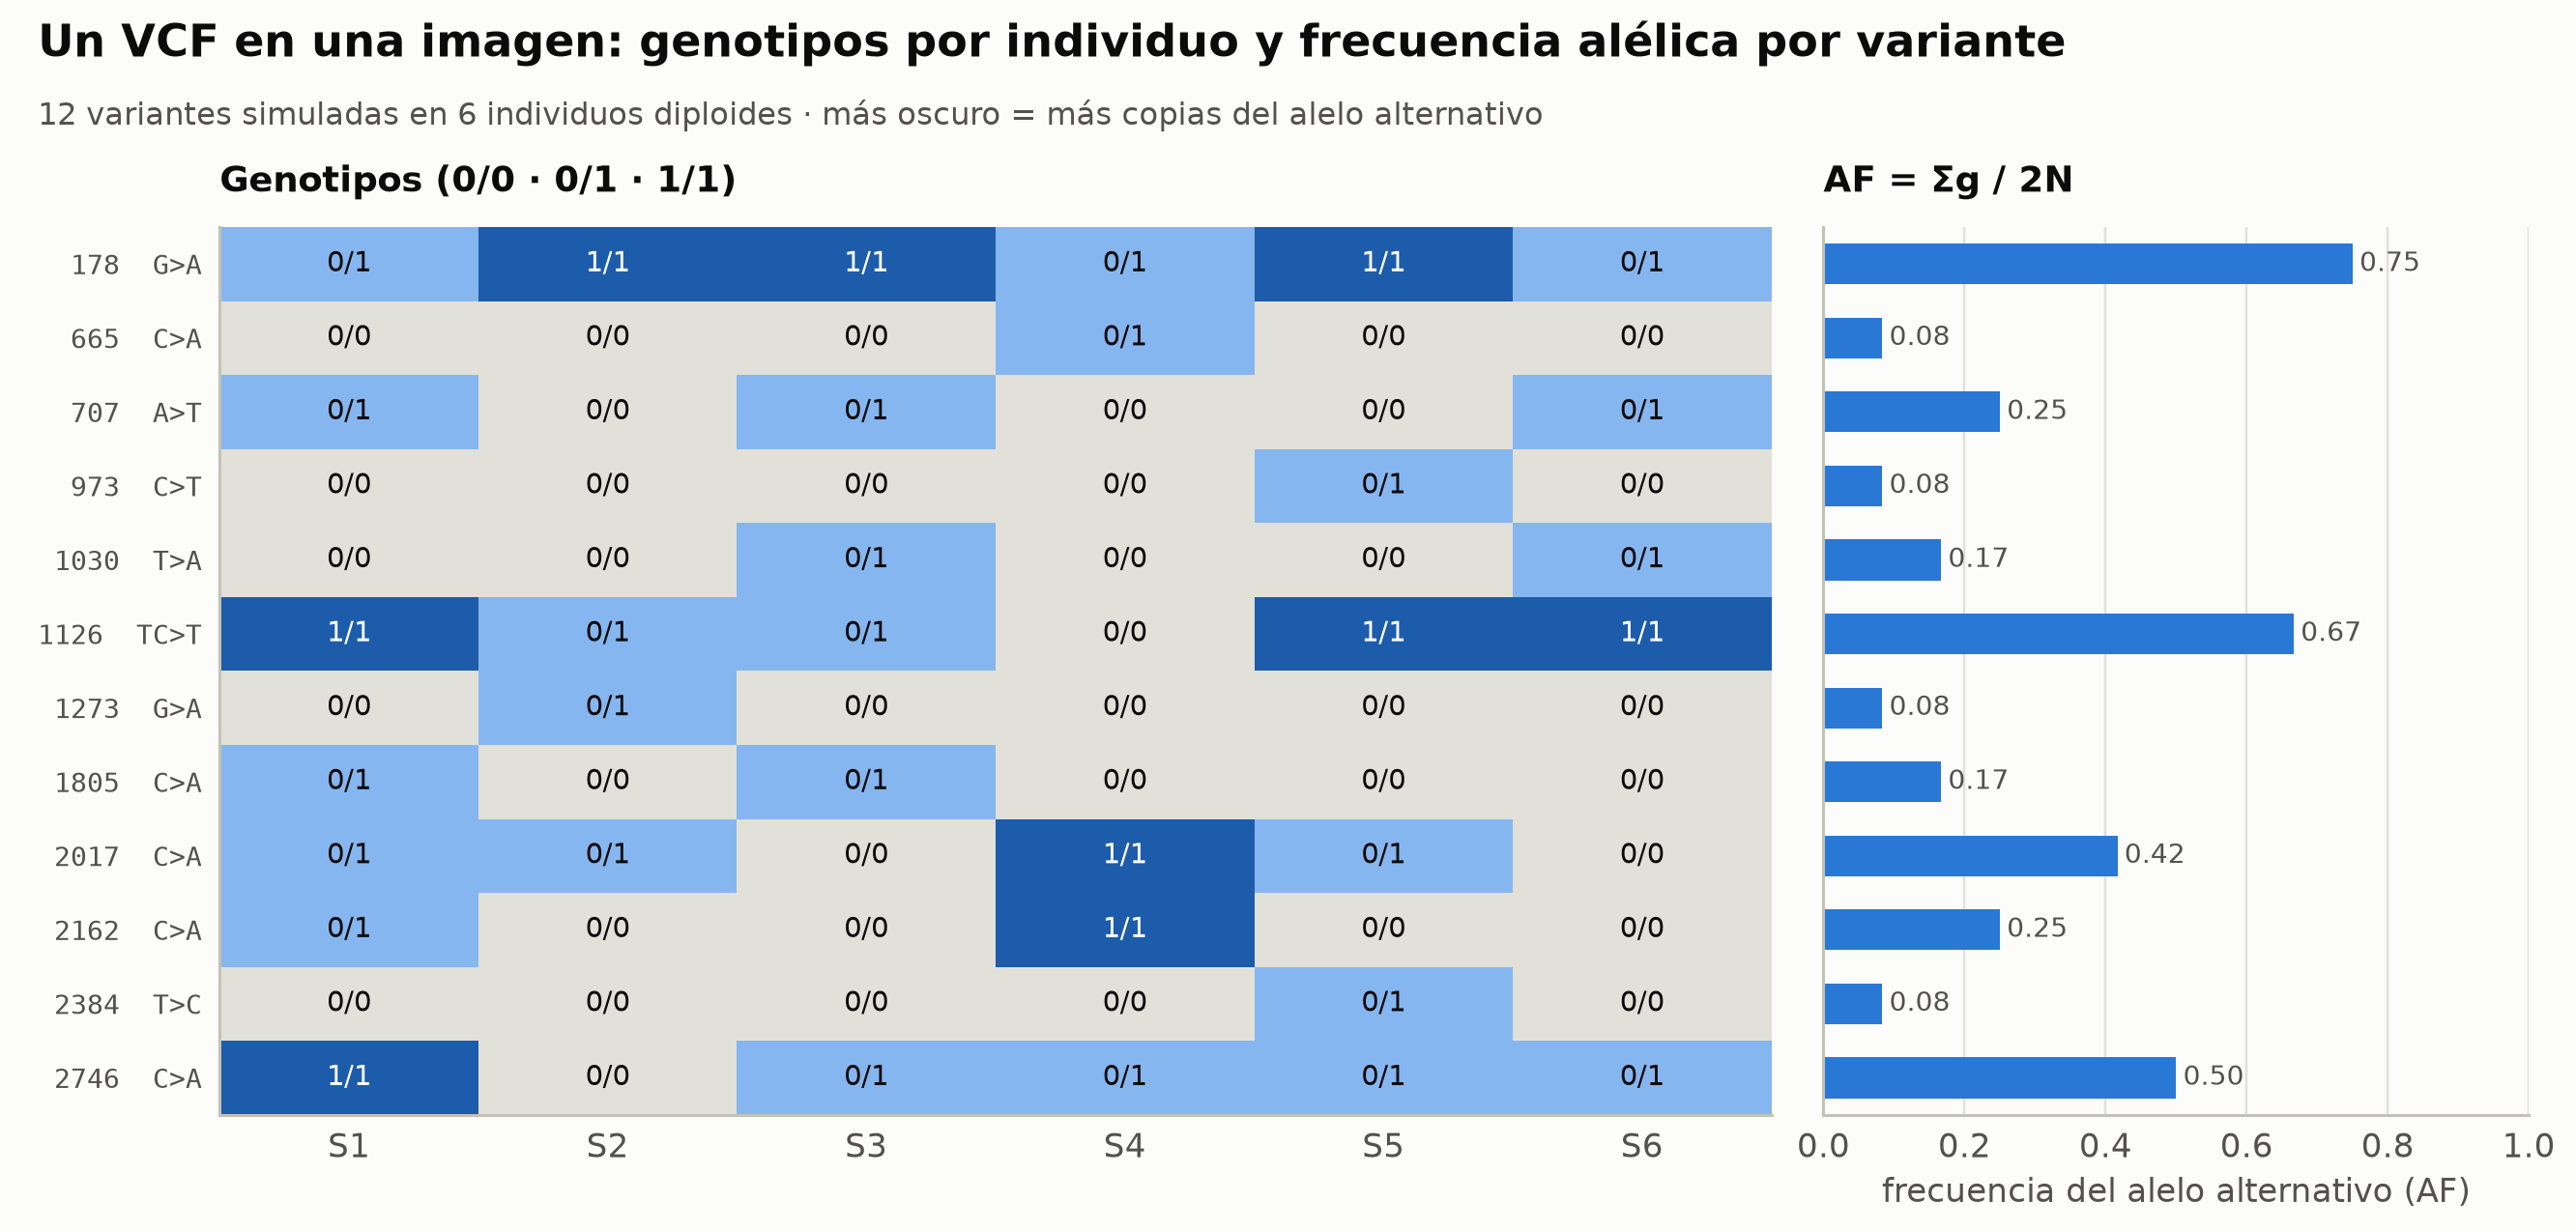

In [33]:
fig, (ax, axf) = plt.subplots(1, 2, figsize=(12, 5), width_ratios=[2.2, 1], sharey=True)
cmap = plt.matplotlib.colors.ListedColormap([ec.GRID, ec.SEQ_BLUE[3], ec.SEQ_BLUE[9]])
ax.imshow(dosage.values, cmap=cmap, vmin=0, vmax=2, aspect="auto")
for i in range(dosage.shape[0]):
    for j in range(dosage.shape[1]):
        v = gt.values[i, j]
        ax.text(j, i, v, ha="center", va="center", fontsize=9.5, color="white" if dosage.values[i, j] == 2 else ec.INK)
ax.set_xticks(range(len(samples))); ax.set_xticklabels(samples)
labels = [f"{p:>5}  {r}>{a}" for p, r, a in zip(vcf["POS"], vcf["REF"], vcf["ALT"])]
ax.set_yticks(range(len(vcf))); ax.set_yticklabels(labels, family="DejaVu Sans Mono", fontsize=9)
ax.grid(False); ax.set_title("Genotipos (0/0 · 0/1 · 1/1)", fontsize=12)
axf.barh(range(len(vcf)), vcf["AF"], color=ec.BLUE, height=0.55)
for i, v in enumerate(vcf["AF"]):
    axf.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=9, color=ec.INK_2)
axf.set_xlim(0, 1); axf.set_xlabel("frecuencia del alelo alternativo (AF)")
axf.grid(axis="y", visible=False); axf.grid(axis="x", visible=True)
axf.set_title("AF = Σg / 2N", fontsize=12)
ec.fig_title(fig, "Un VCF en una imagen: genotipos por individuo y frecuencia alélica por variante",
             "12 variantes simuladas en 6 individuos diploides · más oscuro = más copias del alelo alternativo")
plt.show()

🔎 **Qué observamos.** Cada fila del VCF se lee en horizontal (una variante en todos los individuos) y cada columna
en vertical (un individuo en todas las variantes). La frecuencia alélica resume cada fila en un número; en el
Módulo 10 la usaremos para estudiar poblaciones (equilibrio de Hardy-Weinberg, GWAS).

## ✍️ Ejercicios

**Ejercicio 1 — Phred.** (a) ¿Qué calidad Phred corresponde a $P = 0.0005$? (b) ¿Qué carácter Phred+33 la
representa? (c) Decodifique la cadena de calidad `5?I+`.

**Ejercicio 2 — Filtro por errores esperados.** Con las lecturas simuladas (`Q`), calcule qué fracción de lecturas
sobrevive a los filtros EE ≤ 0.5, 1 y 2. Compare con el filtro "calidad media ≥ 30". ¿Cuál es más estricto?

**Ejercicio 3 — Coordenadas.** Convierta a BED las siguientes regiones GFF: `(1, 100)`, `(266, 21555)` y
`(29558, 29674)`. Verifique que la longitud se conserva.

**Ejercicio 4 — CIGAR.** Para `3S40M1I20M5D30M2S`: (a) longitud de la lectura; (b) tramo en la referencia;
(c) si POS = 1000, ¿en qué posición (1-based) termina el alineamiento?

**Ejercicio 5 — FLAG.** Decodifique las FLAG 83 y 2064 y explique en palabras qué le pasó a cada lectura.

In [34]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
qv = -10 * np.log10(0.0005)
print(f"(a) Q = {qv:.1f} ≈ {round(qv)}   (b) carácter = {phred_to_char(round(qv))!r}")
print("(c) '5?I+' →", [char_to_phred(ch) for ch in "5?I+"])

(a) Q = 33.0 ≈ 33   (b) carácter = 'B'
(c) '5?I+' → [20, 30, 40, 10]


In [35]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
for thr in [0.5, 1, 2]:
    print(f"EE ≤ {thr}: sobrevive {np.mean(EE <= thr):.1%}")
print(f"Calidad media ≥ 30: sobrevive {np.mean(Q.mean(1) >= 30):.1%}")
both = (EE <= 1) & (Q.mean(1) < 30)
print(f"Lecturas con EE ≤ 1 pero calidad media < 30: {both.mean():.1%} (la media las descarta aunque casi no tengan errores)")
worst = np.argmax(np.where(Q.mean(1) >= 30, EE, 0))
print(f"Lectura con media ≥ 30 pero mayor EE: media = {Q[worst].mean():.1f}, EE = {EE[worst]:.2f}, "
      f"Q mínima = {Q[worst].min()} (la media esconde sus bases malas)")

EE ≤ 0.5: sobrevive 93.3%
EE ≤ 1: sobrevive 94.2%
EE ≤ 2: sobrevive 96.0%
Calidad media ≥ 30: sobrevive 85.8%
Lecturas con EE ≤ 1 pero calidad media < 30: 11.2% (la media las descarta aunque casi no tengan errores)
Lectura con media ≥ 30 pero mayor EE: media = 30.1, EE = 2.87, Q mínima = 4 (la media esconde sus bases malas)


In [36]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
for s, e in [(1, 100), (266, 21555), (29558, 29674)]:
    b = one_to_zero(s, e)
    print(f"GFF {s}-{e} (long {e - s + 1}) → BED {b[0]}\t{b[1]} (long {b[1] - b[0]})")

GFF 1-100 (long 100) → BED 0	100 (long 100)
GFF 266-21555 (long 21290) → BED 265	21555 (long 21290)
GFF 29558-29674 (long 117) → BED 29557	29674 (long 117)


In [37]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
c = "3S40M1I20M5D30M2S"
print("(a) lectura =", query_length(c), "  (b) referencia =", ref_span(c),
      "  (c) fin =", 1000 + ref_span(c) - 1)

(a) lectura = 96   (b) referencia = 95   (c) fin = 1094


In [38]:
#@title 🔑 Solución — Ejercicio 5 { display-mode: "form" }
for f in [83, 2064]:
    print(f, "→", decode_flag(f))
print("83: R1 de un par bien alineado, en la hebra reversa (su pareja en la directa).")
print("2064: alineamiento suplementario en la hebra reversa: parte de una lectura quimérica que cae en otro lugar.")

83 → ['pareada', 'par correcto', 'hebra reversa', 'R1']
2064 → ['hebra reversa', 'suplementaria']
83: R1 de un par bien alineado, en la hebra reversa (su pareja en la directa).
2064: alineamiento suplementario en la hebra reversa: parte de una lectura quimérica que cae en otro lugar.


## 📌 Resumen

* Cada formato responde a una pregunta: **FASTA** (secuencia), **FASTQ** (lecturas + confianza), **GenBank/GFF/BED**
  (anotaciones e intervalos), **SAM/BAM** (alineamientos) y **VCF** (variantes).
* La calidad Phred es logarítmica: $Q = -10\log_{10}P$; se guarda como `chr(Q + 33)`. Los **errores esperados**
  $\mathrm{EE} = \sum 10^{-Q/10}$ resumen una lectura mejor que la calidad media.
* Hay dos sistemas de coordenadas: **1-based cerrado** (GFF, SAM, VCF) y **0-based semiabierto** (BED, Python).
  $\text{inicio}_0 = \text{inicio}_1 - 1$ y el fin no cambia. Verificar que **REF coincide con la referencia** atrapa
  los errores de uno.
* En SAM, la **CIGAR** describe cómo encaja la lectura (M, I, D, S…) y la **FLAG** guarda 12 bits de información.
* **BAM** = SAM comprimido en bloques (BGZF); ordenado e **indexado** permite ir directo a una región.
* En VCF, los genotipos `0/0, 0/1, 1/1` dan la frecuencia alélica $\mathrm{AF} = \sum g_i / 2N$.

**Próxima lección (2.2):** NCBI, Ensembl, UniProt y PDB — consultas programáticas a las grandes bases de datos.

## 📚 Para profundizar

* Cock, P. J. A. *et al.* (2010). The Sanger FASTQ file format for sequences with quality scores, and the
  Solexa/Illumina FASTQ variants. *Nucleic Acids Research* 38(6): 1767–1771.
* Ewing, B. & Green, P. (1998). Base-calling of automated sequencer traces using *phred*. II. Error probabilities.
  *Genome Research* 8(3): 186–194.
* Li, H. *et al.* (2009). The Sequence Alignment/Map format and SAMtools. *Bioinformatics* 25(16): 2078–2079.
* Danecek, P. *et al.* (2011). The variant call format and VCFtools. *Bioinformatics* 27(15): 2156–2158.
* Quinlan, A. R. & Hall, I. M. (2010). BEDTools: a flexible suite of utilities for comparing genomic features.
  *Bioinformatics* 26(6): 841–842.
* Edgar, R. C. & Flyvbjerg, H. (2015). Error filtering, pair assembly and error correction for next-generation
  sequencing reads. *Bioinformatics* 31(21): 3476–3482.
* Especificaciones oficiales de SAM/BAM/VCF: [samtools.github.io/hts-specs](https://samtools.github.io/hts-specs/).

---

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai)